In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py import ScPredModel 
from scpred_py import _analysis_utils 


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving models and preprocessed data within the project structure
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.


In [2]:
print("\n--- Step 1: Loading and Annotating Data ---")
# Load pbmc3k dataset
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique() # Ensure gene names are unique

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This pipeline is used *only* to create labels for the raw `adata` object.
print("Generating temporary cell type labels via Louvain clustering for demonstration...")
temp_adata_for_labels = adata.copy()

# Basic filtering
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)

# Normalization and log-transformation
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)

# Highly variable gene selection
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()

# Scaling and PCA
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE)

# Neighbors and Louvain clustering for labels
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE)
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type')

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())



--- Step 1: Loading and Annotating Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering for demonstration...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after labeling: ['cell_type']
Cell type distribution (all data):
 cell_type
0    815
1    467
2    459
3    371
4    345
5    184
6     45
7     14
Name: count, dtype: int64


In [3]:
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())

# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())



--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1890, 32738)
Query data (raw + labels) shape: (810, 32738)

Reference cell type distribution:
 cell_type
0    570
1    327
2    321
3    260
4    241
5    129
6     32
7     10
Name: count, dtype: int64

Query cell type distribution:
 cell_type
0    245
1    140
2    138
3    111
4    104
5     55
6     13
7      4
Name: count, dtype: int64

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
0    0.301587
1    0.173016
2    0.169841
3    0.137566
4    0.127513
5    0.068254
6    0.016931
7    0.005291
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
0    0.302469
1    0.172840
2    0.170370
3    0.137037
4    0.128395
5    0.067901
6    0.016049
7    0.004938
Name: proportion, dtype: float64


In [4]:
print("\n--- Step 3: Training scPred Model with Selected Parameters ---")
scpred_model = ScPredModel()

# Applying selected parameters (e.g., RBF kernel, C=10.0, No class weight, 2000 HVGs, 30 PCs)
# These parameters should be based on prior optimization.
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data with generated cell_type annotations
    cell_type_key='cell_type',
    n_components=30, # Example PC count
    hvg_n_top_genes=2000, # Example HVG count
    hvg_flavor='seurat', # Consistent with common practices
    svm_kernel='rbf', # Example SVM kernel
    svm_c=10.0, # Example SVM C parameter
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight=None # Example class weight setting
)

print("\nModel Trained with Selected Parameters!")
print(f"Scaler fitted: {scpred_model.scaler_ is not None}")
print(f"PCA Model fitted: {scpred_model.pca_model_ is not None}")
print(f"Classifier trained: {scpred_model.classifier_ is not None}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")
print(f"Classifier classes: {scpred_model.classifier_.classes_.tolist()}")

# Save the trained ScPredModel object
model_path = os.path.join(MODELS_DIR, 'scpred_model_pbmc3k.pkl')
scpred_model.save(model_path)
print(f"ScPredModel for pbmc3k saved successfully to: {model_path}")

# Note: The preprocessed reference data (scpred_model.ref_adata_processed_) is stored internally
# within the model for consistency but not explicitly saved here as a separate .h5ad file,
# as the model itself can be loaded.



--- Step 3: Training scPred Model with Selected Parameters ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---

Model Trained with Selected Parameters!
Scaler fitted: True
PCA Model fitted: True
Classifier trained: True
Reference HVGs learned: 2000 genes
Classifier classes: ['0', '1', '2', '3', '4', '5', '6', '7']
Saving ScPredModel to ../models/scpred_model_pbmc3k.pkl...
ScPre

In [5]:
# --- Fully Comprehensive Plotting Helper Function ---
def plot_results_comprehensive(adata_pred, true_labels, predicted_labels, classifier_classes, y_pred_probs_df, scenario_title, threshold_val, random_state):
    """
    Fully comprehensive plotting function for scPred results.
    """
    print(f"\n--- Visualizing Results ({scenario_title}) ---")

    # UMAP computation
    if 'X_scpred_pca' in adata_pred.obsm:
        print("Computing neighbors and UMAP based on X_scpred_pca...")
        sc.pp.neighbors(adata_pred, n_neighbors=10, use_rep='X_scpred_pca', random_state=random_state)
        sc.tl.umap(adata_pred, random_state=random_state)
    else:
        print("X_scpred_pca not found. Skipping UMAP plots.")
        return

    # Plot 1: Confusion Matrix
    print(f"\n--- Confusion Matrix ({scenario_title}) ---")
    all_labels_for_cm = sorted(list(set(true_labels.astype(str)) | set(predicted_labels.astype(str))))
    cm = confusion_matrix(true_labels, predicted_labels, labels=all_labels_for_cm)
    cm_df = pd.DataFrame(cm, index=all_labels_for_cm, columns=all_labels_for_cm)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (pbmc3k - {scenario_title})')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label')
    plt.show()

    # Plot 2: Per-Class ROC AUC Curves
    print(f"\n--- Per-Class ROC AUC ({scenario_title}) ---")
    plt.figure(figsize=(10, 8))
    for class_label in sorted(classifier_classes):
        y_true_binary = (true_labels == class_label)
        if len(np.unique(y_true_binary)) > 1:
            prob_col_name = f"scpred_prob_{class_label}"
            y_score = y_pred_probs_df[prob_col_name]
            fpr, tpr, _ = roc_curve(y_true_binary, y_score)
            roc_auc_score = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)'); plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate'); plt.title(f'ROC Curve (pbmc3k - {scenario_title})')
    plt.legend(loc="lower right"); plt.grid(True); plt.show()

    # Probability Distribution Plots
    plot_df_probs = adata_pred.obs.copy()
    
    # Plot 3: Distribution of Prediction Probabilities (Per True Cell Type)
    print(f"\n--- Distribution of Prediction Probabilities (Per True Cell Type, {scenario_title}) ---")
    prob_melted = plot_df_probs.melt(
        id_vars=['cell_type'], value_vars=[f"scpred_prob_{c}" for c in classifier_classes],
        var_name='probability_of_class', value_name='probability_value'
    )
    prob_melted['probability_of_class'] = prob_melted['probability_of_class'].str.replace('scpred_prob_', '')
    for true_type in sorted(plot_df_probs['cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted[prob_melted['cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='probability_of_class', y='probability_value', hue='probability_of_class', palette='viridis', legend=False)
        if threshold_val > 0:
            plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} ({scenario_title})')
        plt.xlabel('Probability of being Predicted as Class'); plt.ylabel('Probability')
        plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()
        
    # Plot 4 & 5: Max Prediction Probability per True and Predicted Label
    if 'max_prob_value' in plot_df_probs.columns:
        print(f"\n--- Max Prediction Probability per True Cell Type ({scenario_title}) ---")
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_df_probs, x='cell_type', y='max_prob_value', hue='cell_type', palette='viridis', legend=False)
        if threshold_val > 0: plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Max Prediction Probability per True Cell Type ({scenario_title})')
        plt.xlabel('True Cell Type'); plt.ylabel('Max Predicted Probability')
        plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()

        print(f"\n--- Max Prediction Probability per Predicted Label ({scenario_title}) ---")
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_df_probs, x='scpred_prediction', y='max_prob_value', hue='scpred_prediction', palette='viridis', legend=False, order=sorted(plot_df_probs['scpred_prediction'].unique()))
        if threshold_val > 0: plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Max Prediction Probability per Predicted Label ({scenario_title})')
        plt.xlabel('Predicted Label'); plt.ylabel('Max Predicted Probability')
        plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()

    # UMAP Plots
    print(f"\n--- UMAP Visualizations ({scenario_title}) ---")
    sc.pl.umap(adata_pred, color=['cell_type', 'scpred_prediction'], title=['True Labels', f'scPred Predictions'], frameon=False, wspace=0.4)
    
    # Misclassified UMAP
    adata_pred.obs['misclassified'] = (adata_pred.obs['cell_type'].astype(str) != adata_pred.obs['scpred_prediction'].astype(str)).astype(str)
    sc.pl.umap(adata_pred, color='misclassified', palette={'True': 'red', 'False': 'lightgray'}, title='Misclassified Cells', frameon=False)
    
    # Confidence UMAP
    if 'max_prob_value' in adata_pred.obs.columns:
        sc.pl.umap(adata_pred, color='max_prob_value', cmap='viridis', title='Prediction Confidence', frameon=False, vmin=0.0, vmax=1.0)


# Function to run a full scenario
def run_scenario(scpred_model, query_adata_raw, threshold, scenario_name, random_state):
    print(f"\n\n======== {scenario_name} ========")
    query_adata_pred = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)
    
    print("\nQuery Data with Predictions (first 5 rows):")
    print(query_adata_pred.obs[['cell_type', 'scpred_prediction']].head())
    print("\nPredicted label distribution:\n", query_adata_pred.obs['scpred_prediction'].value_counts(dropna=False))

    # Calculate max probability and add to .obs BEFORE plotting
    prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
    query_adata_pred.obs['max_prob_value'] = query_adata_pred.obs[prob_cols].max(axis=1)

    # Filter valid cells for evaluation
    valid_cells_mask = query_adata_pred.obs['scpred_prediction'].notna()
    true_labels = query_adata_pred.obs['cell_type'][valid_cells_mask]
    predicted_labels = query_adata_pred.obs['scpred_prediction'][valid_cells_mask]
    y_pred_probs_df = query_adata_pred.obs.loc[valid_cells_mask, prob_cols].copy()

    print(f"\n--- Evaluating Predictions ({scenario_name}) ---")
    _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels, predicted_labels=predicted_labels,
        classifier_classes=scpred_model.classifier_.classes_, y_pred_probs=y_pred_probs_df
    )

    plot_results_comprehensive(
        adata_pred=query_adata_pred[valid_cells_mask].copy(),
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=scpred_model.classifier_.classes_,
        y_pred_probs_df=y_pred_probs_df,
        scenario_title=scenario_name,
        threshold_val=threshold,
        random_state=random_state
    )




======== ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0) ========
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 11316 genes to 2000 reference genes...
  Note: 237 reference genes were missing in the query data and filled with zeros.
  Note: 9553 query genes were not in the reference and were dropped.
Genes aligned. New shape: (810, 2000)
Transforming data with fitted StandardScaler...
Data scaled.
Projecting data onto existing PCA space...
Projection finished.
Predicting cell types...
No cells fell below the prediction threshold.
Prediction finished.
Projected PCs stored in query_adata.obsm['X_scpred_pca']. Cells filtered during preprocessing will have NaN values.
--- ScPred Prediction Complete ---

Query Data with Predictions (first 5 rows):
                 cell_type scpred

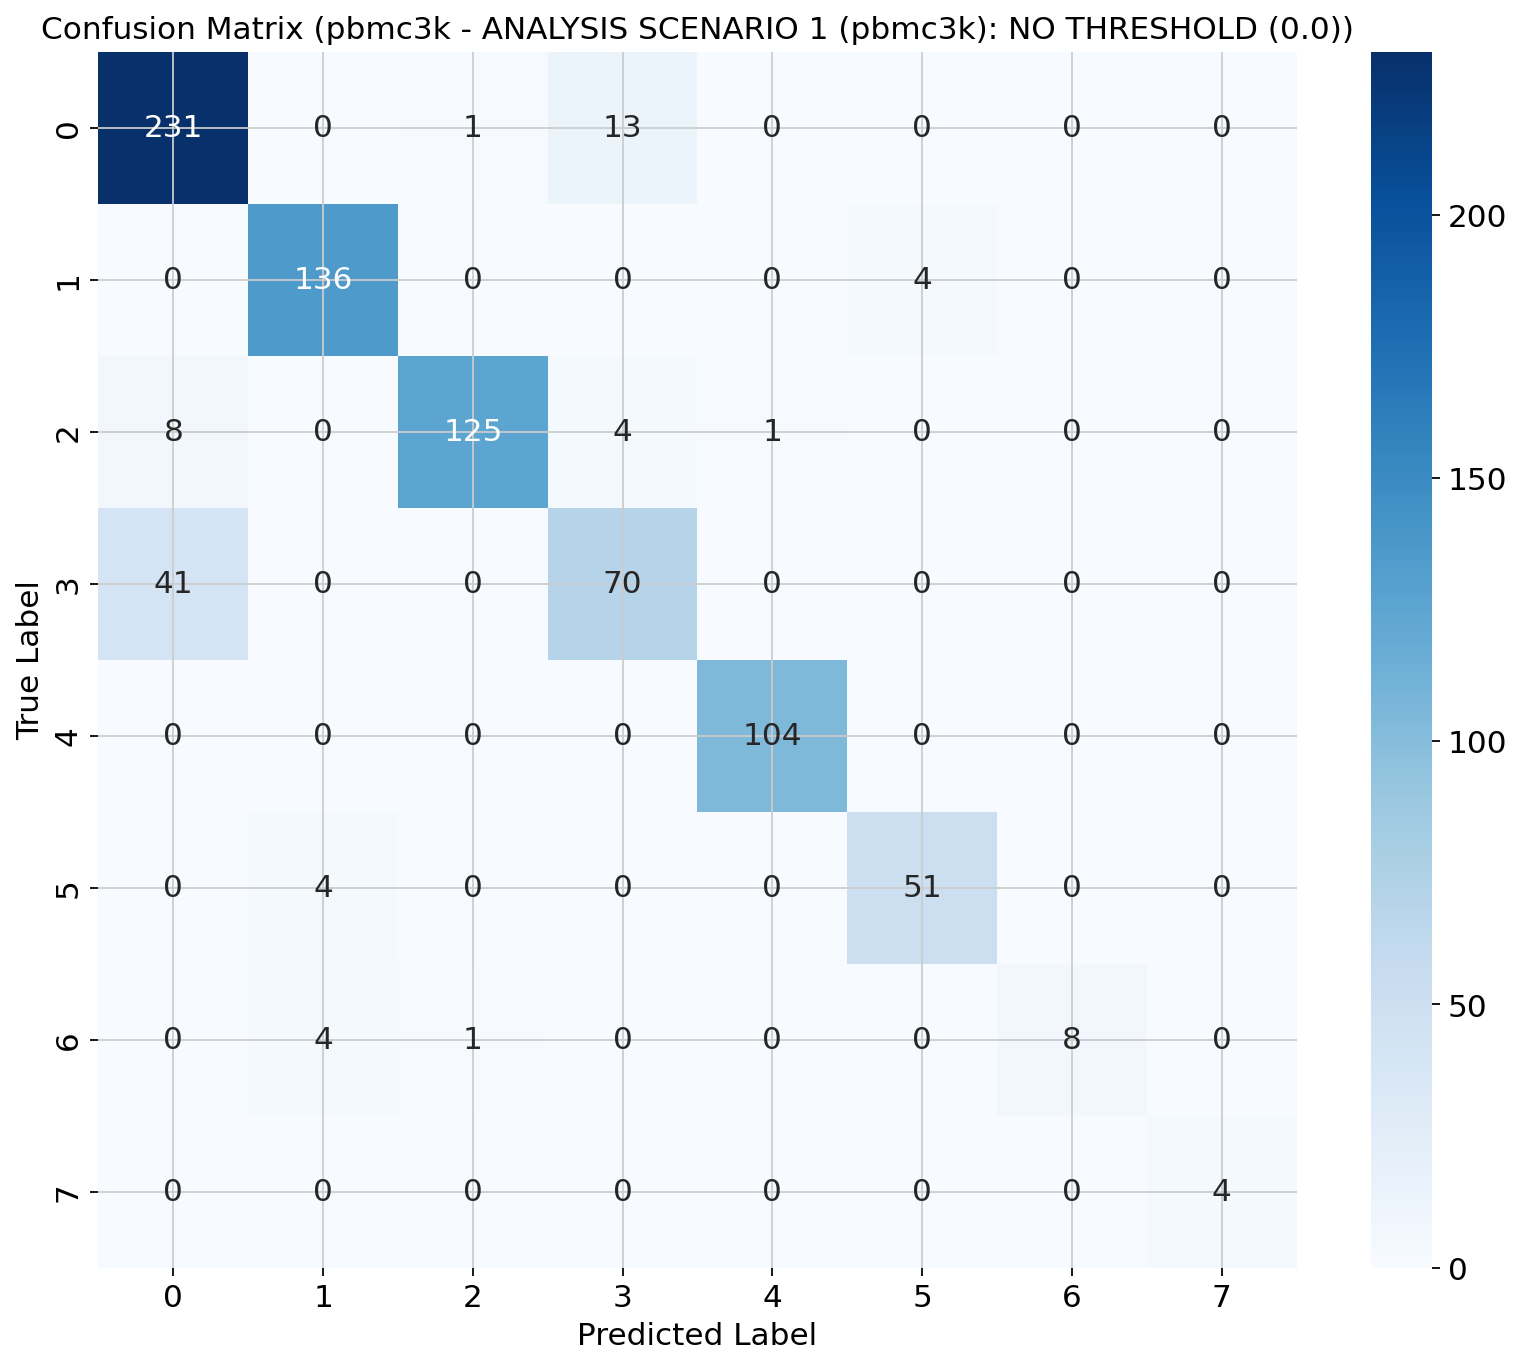


--- Per-Class ROC AUC (ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)) ---


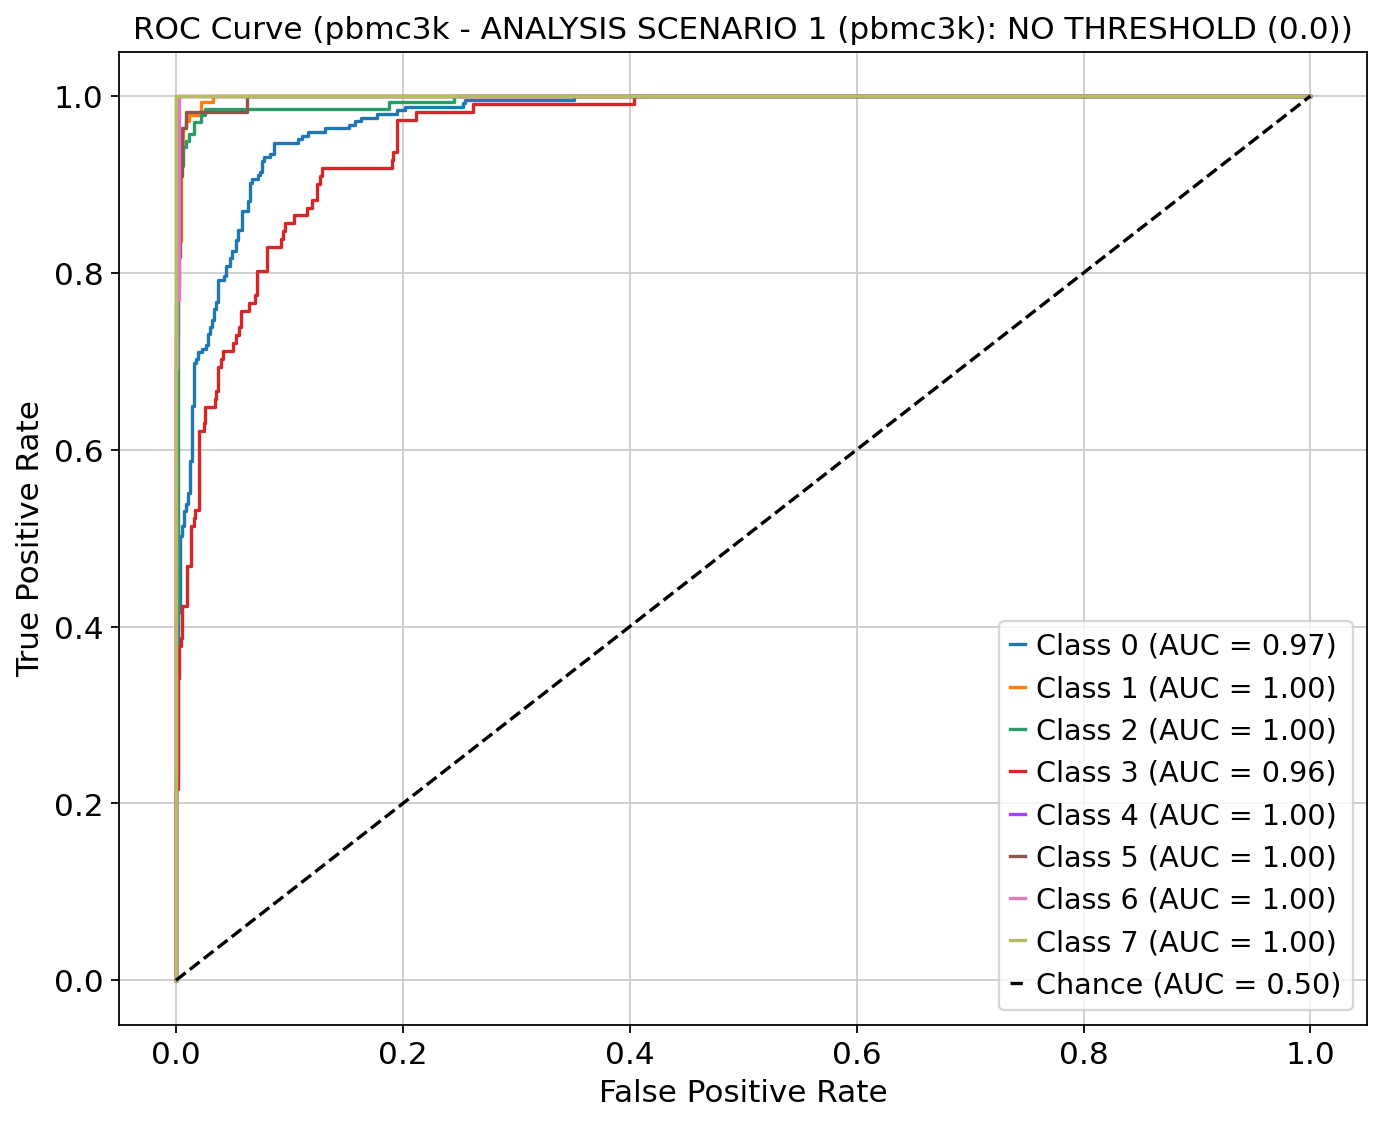


--- Distribution of Prediction Probabilities (Per True Cell Type, ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


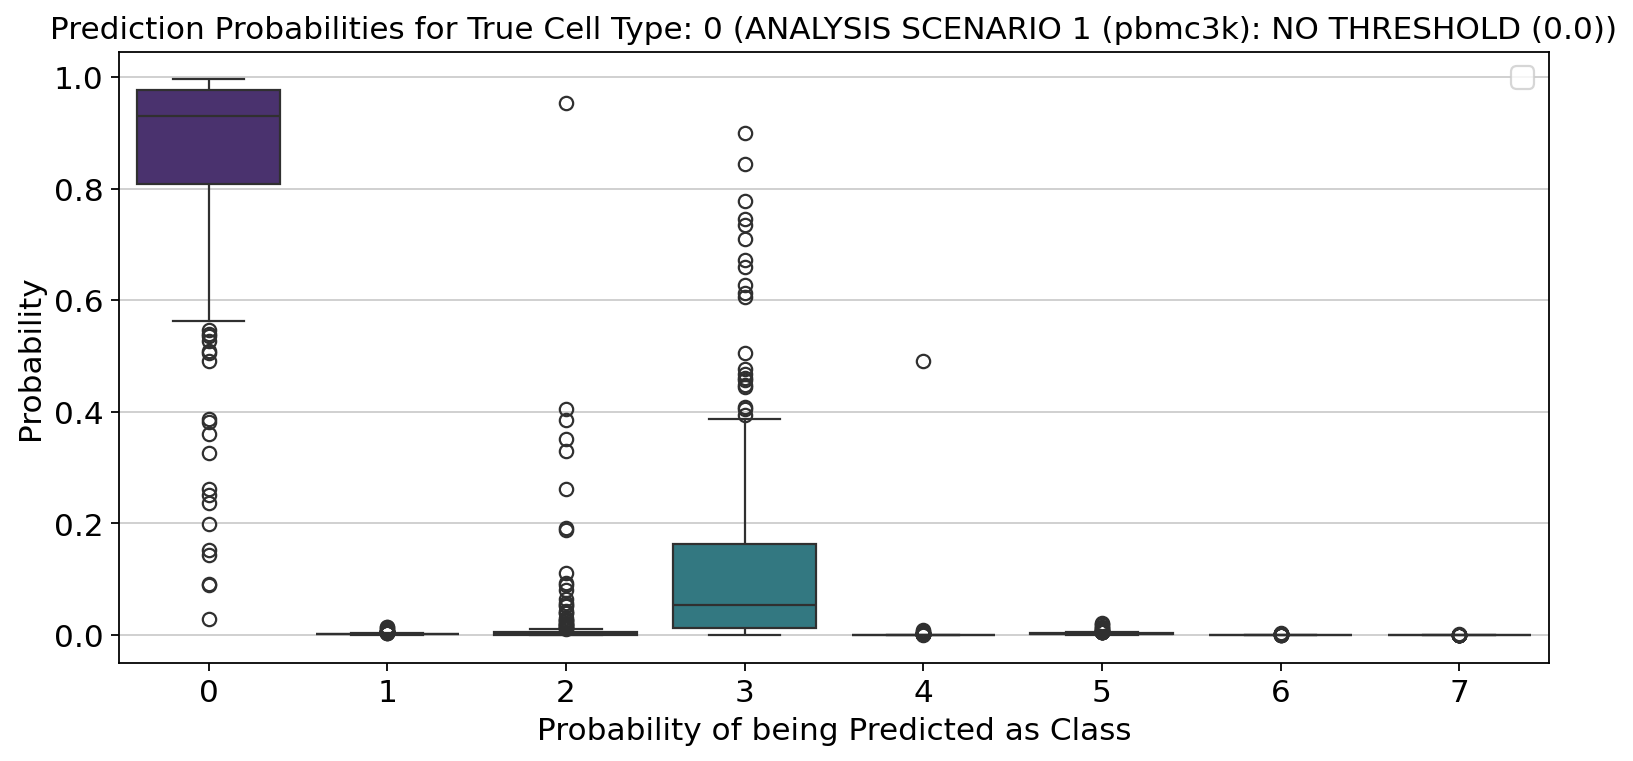

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


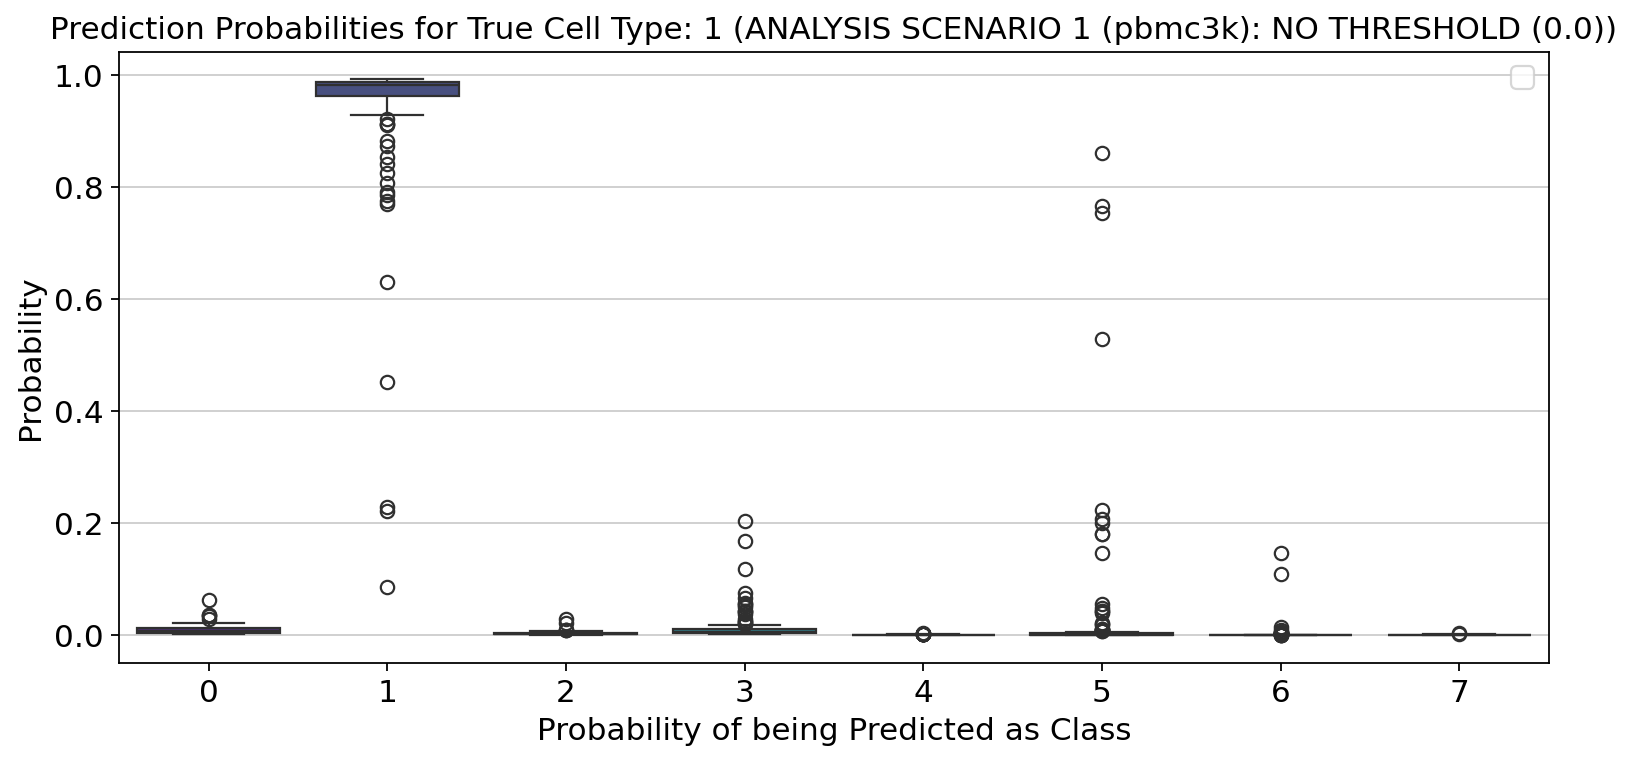

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


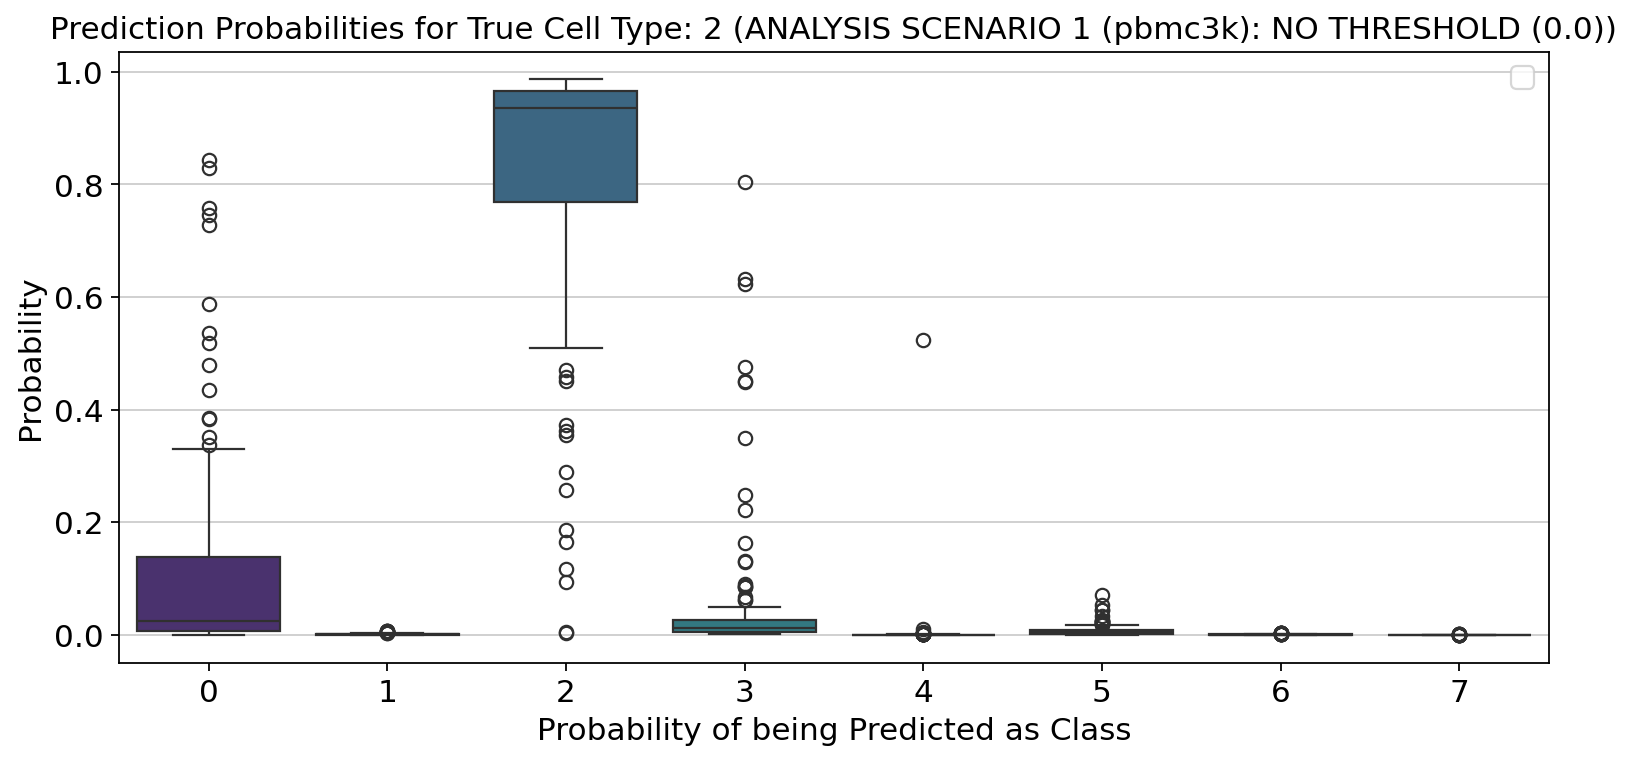

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


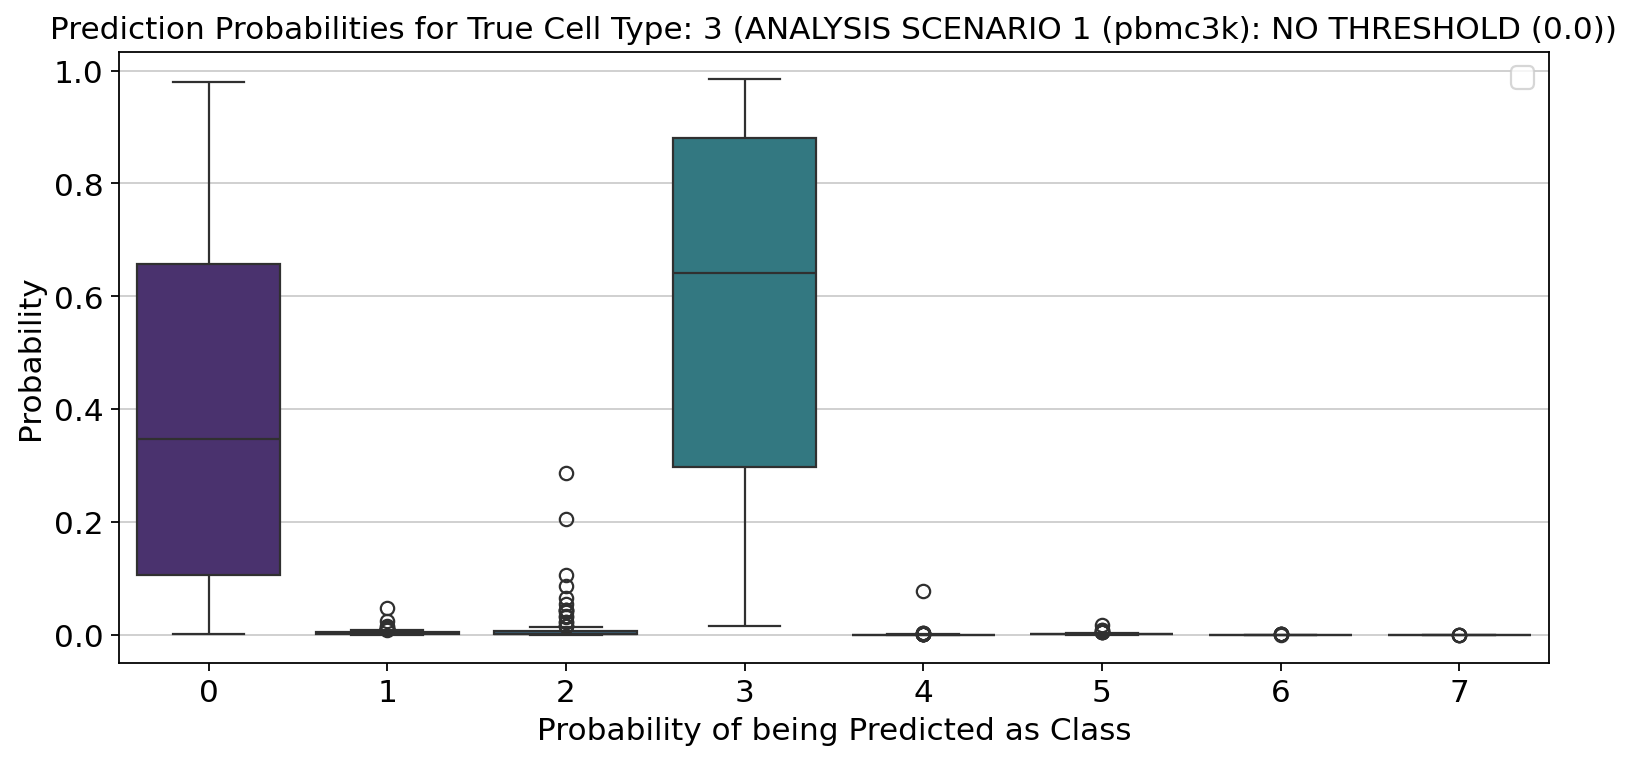

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


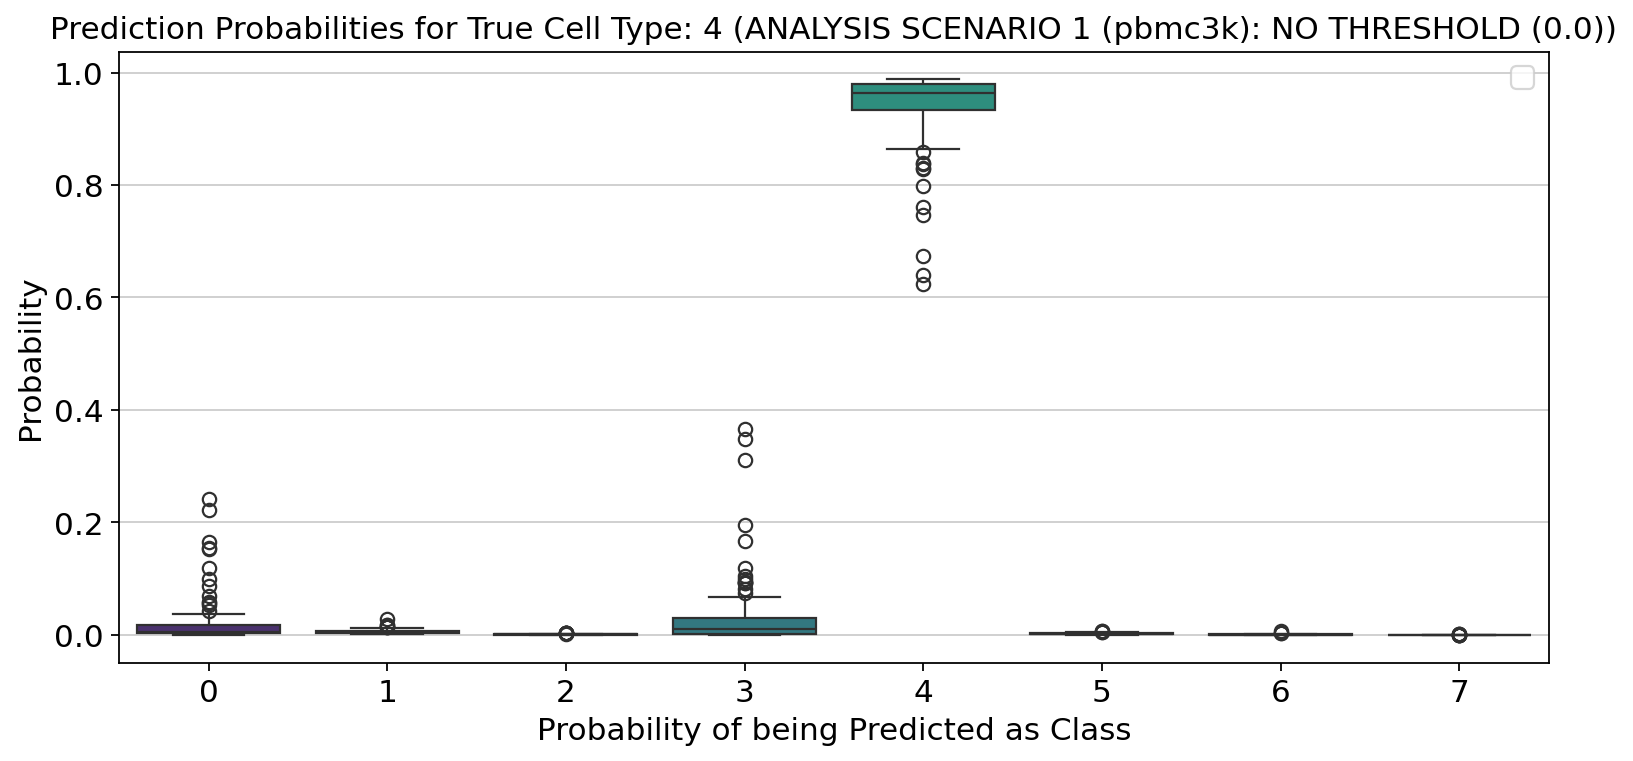

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


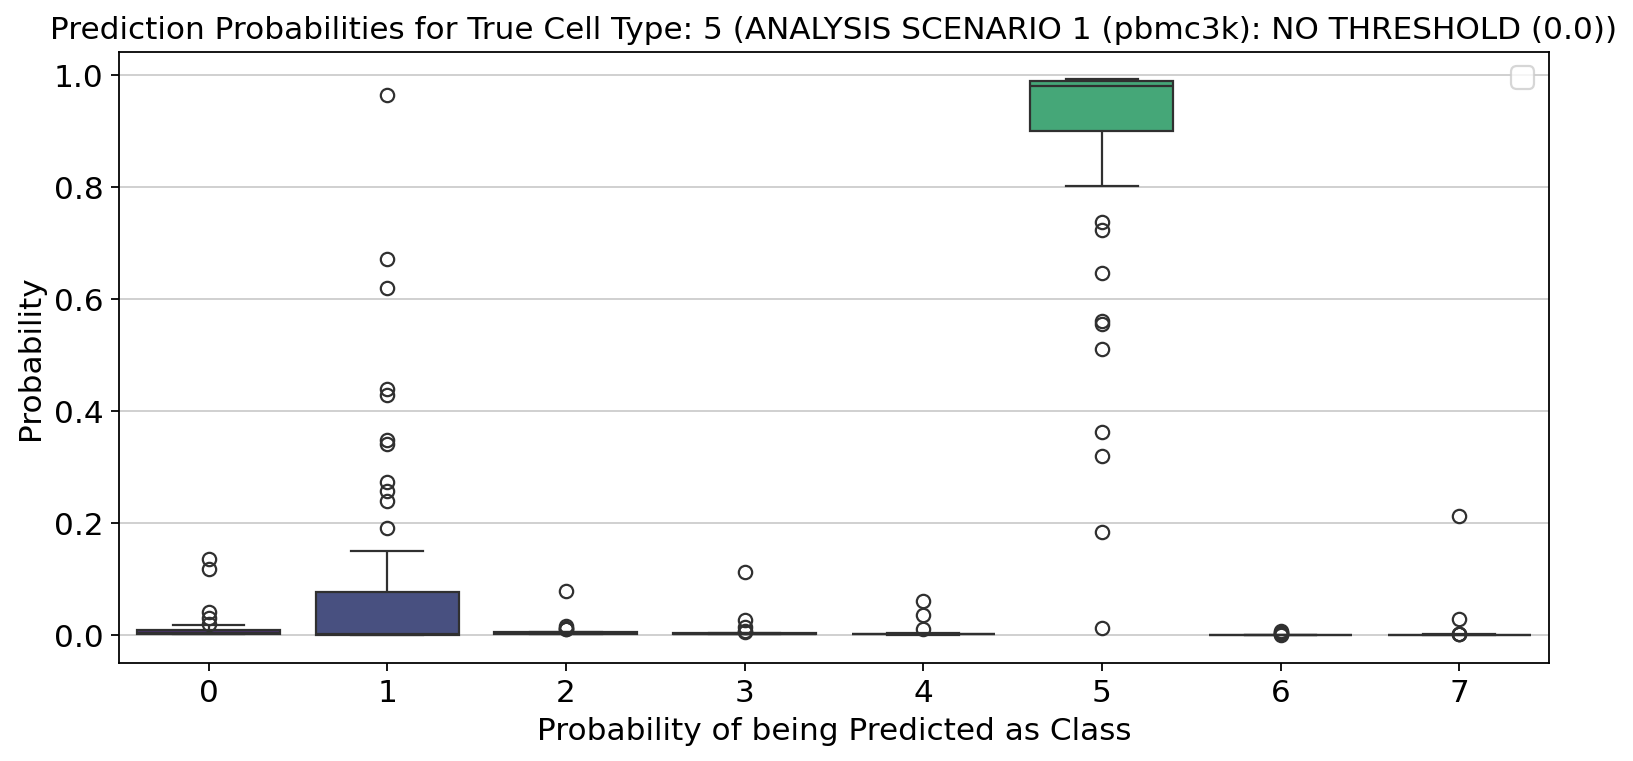

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


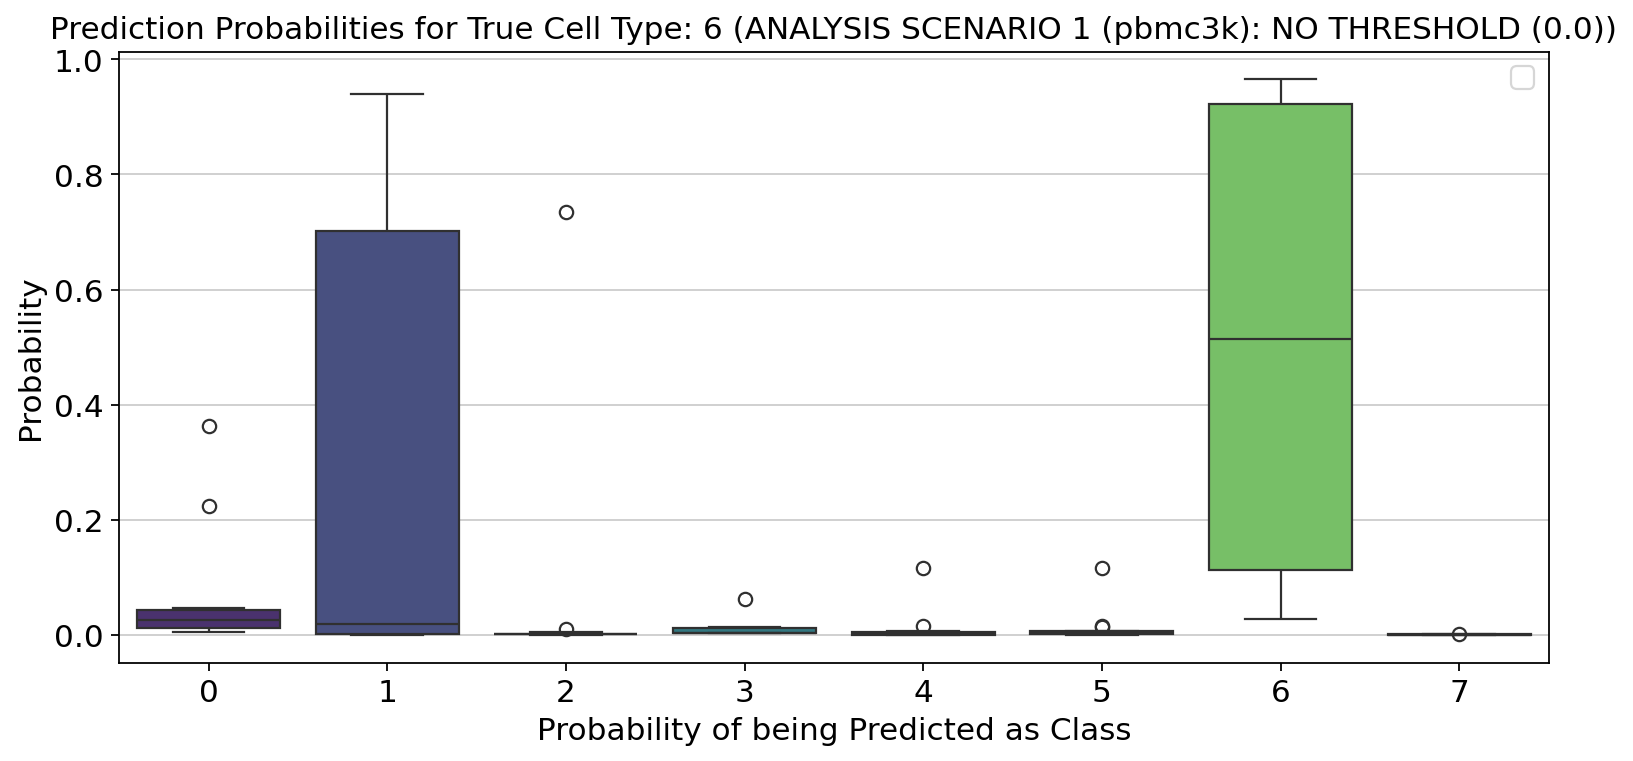

/tmp/ipykernel_101746/2358805085.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


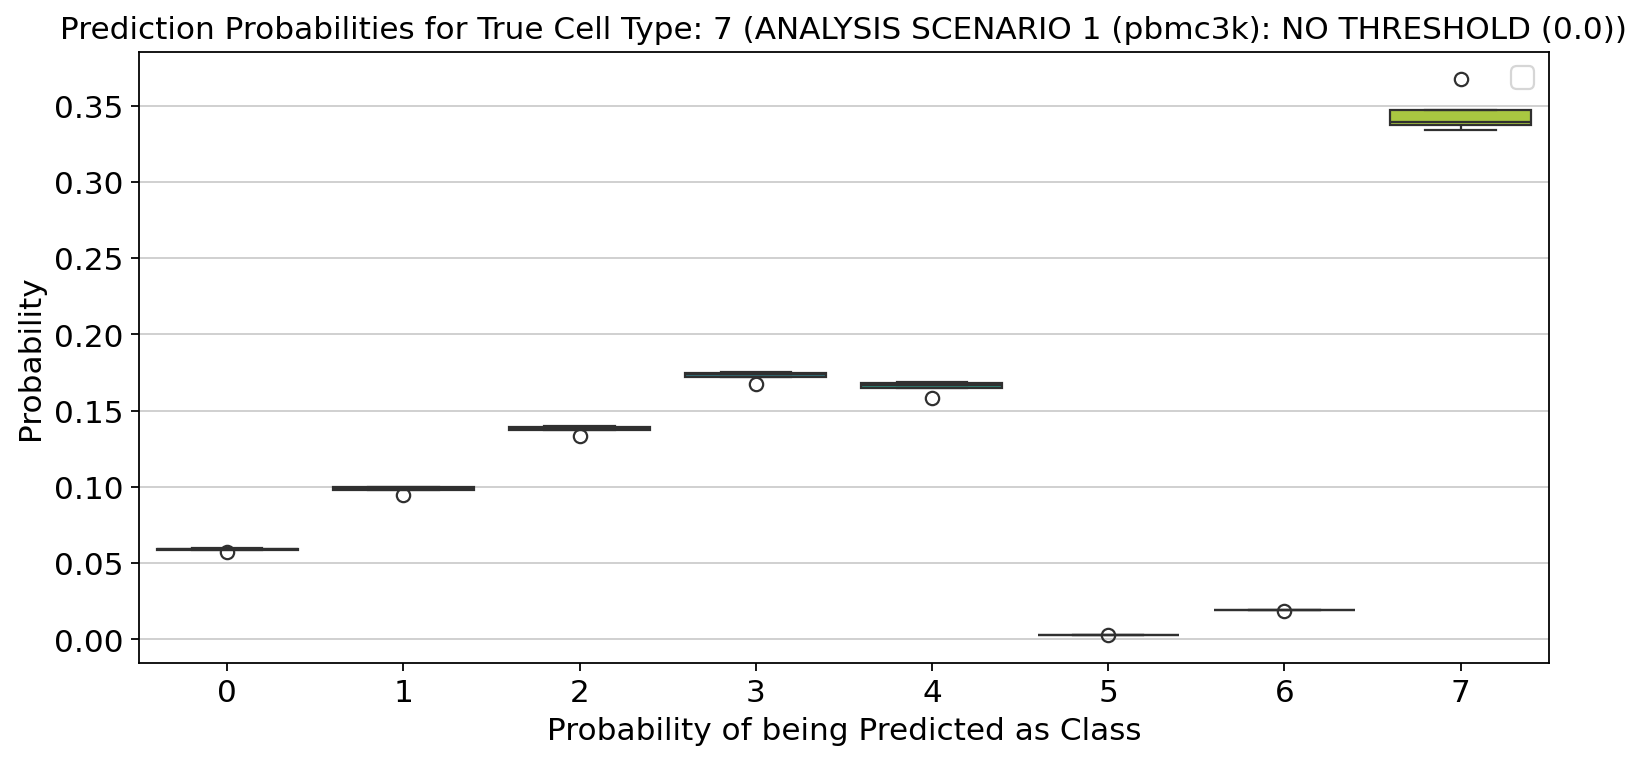


--- Max Prediction Probability per True Cell Type (ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_101746/2358805085.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


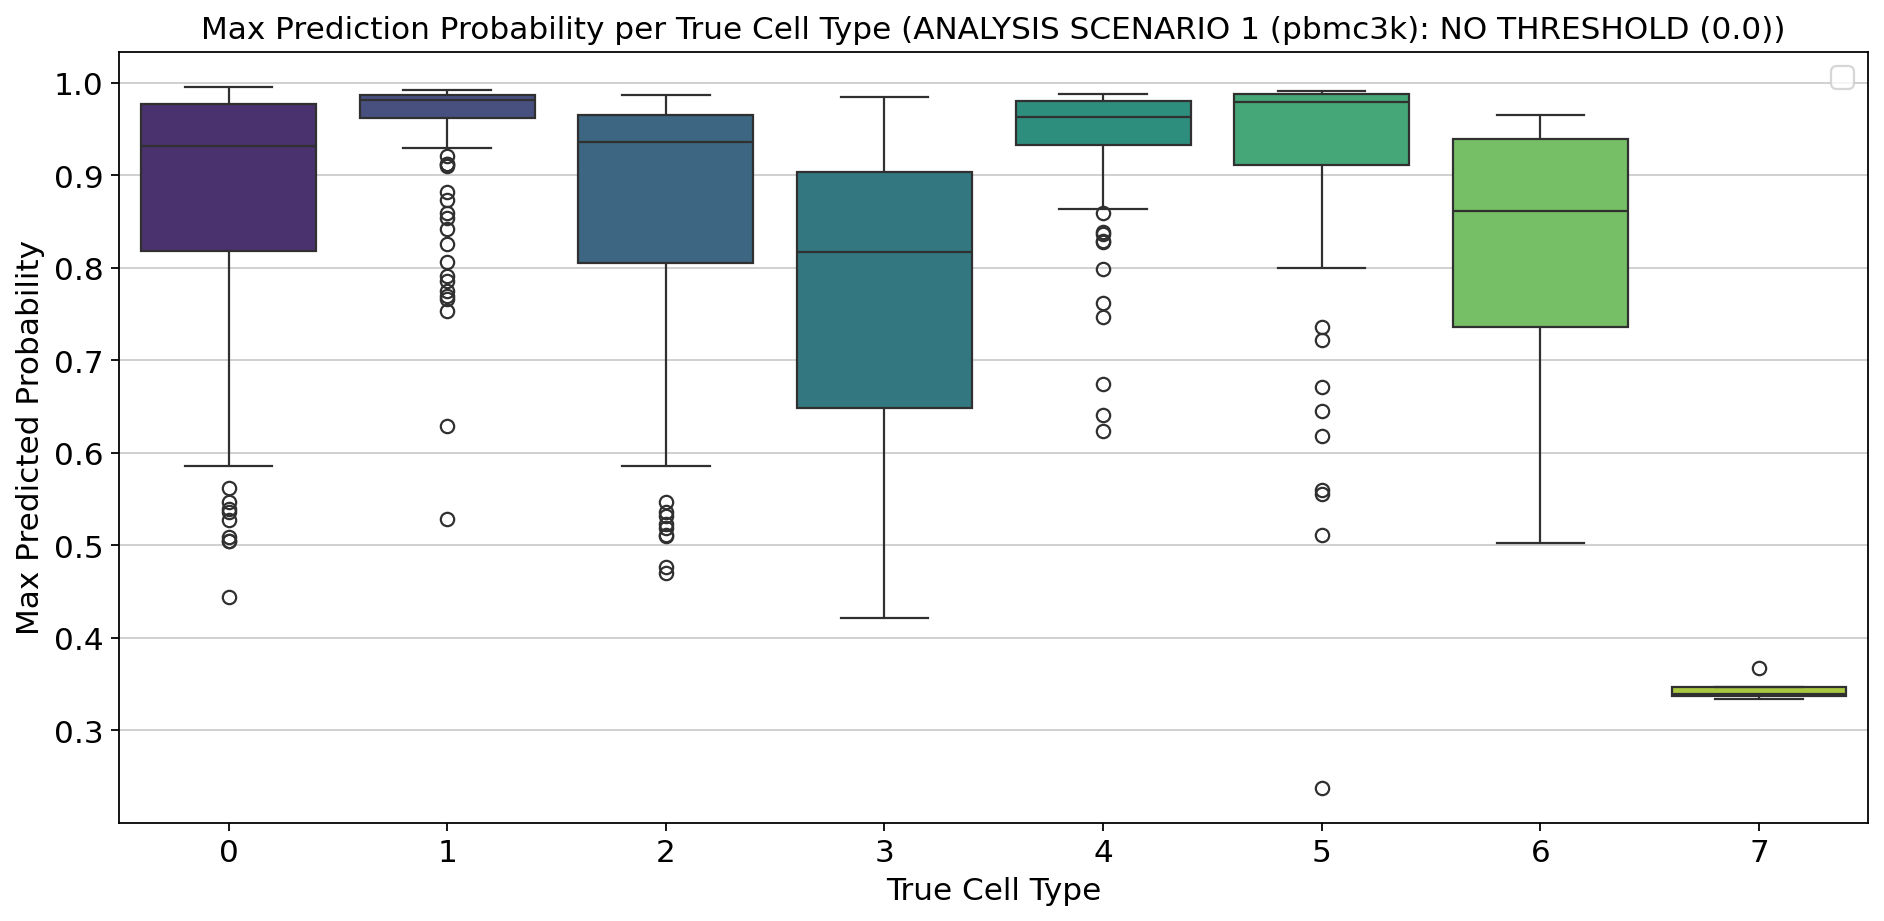


--- Max Prediction Probability per Predicted Label (ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_101746/2358805085.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(); plt.legend(); plt.tight_layout(); plt.show()


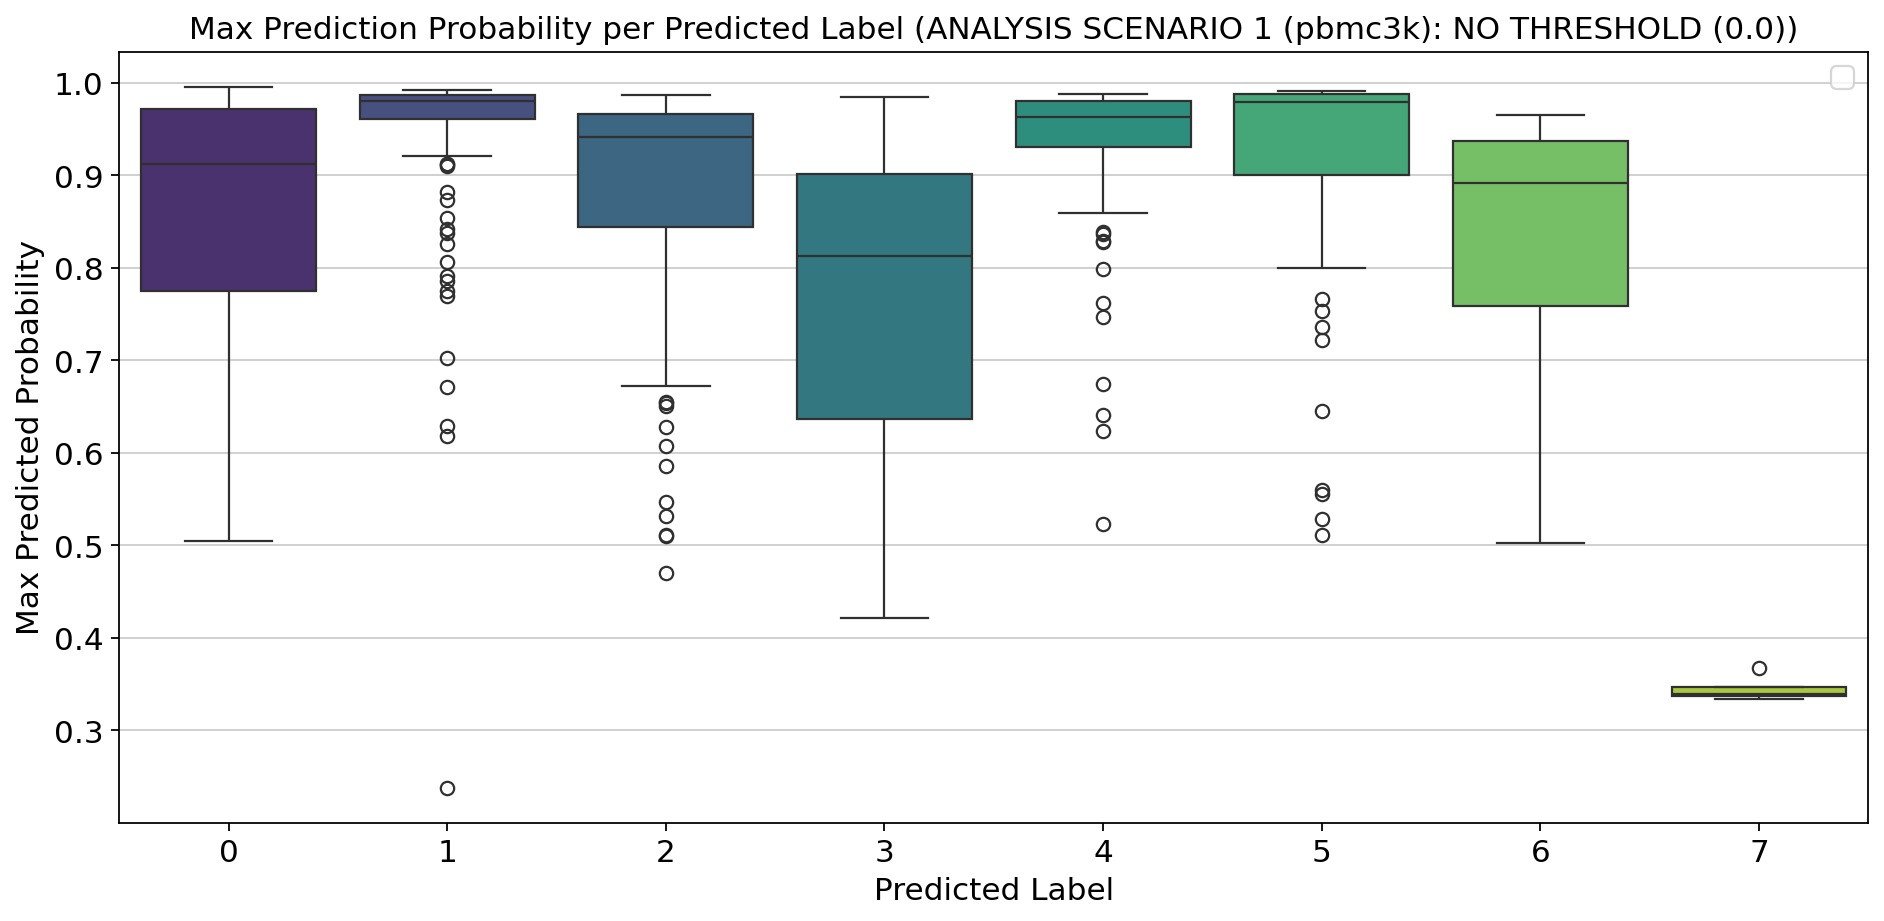


--- UMAP Visualizations (ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)) ---


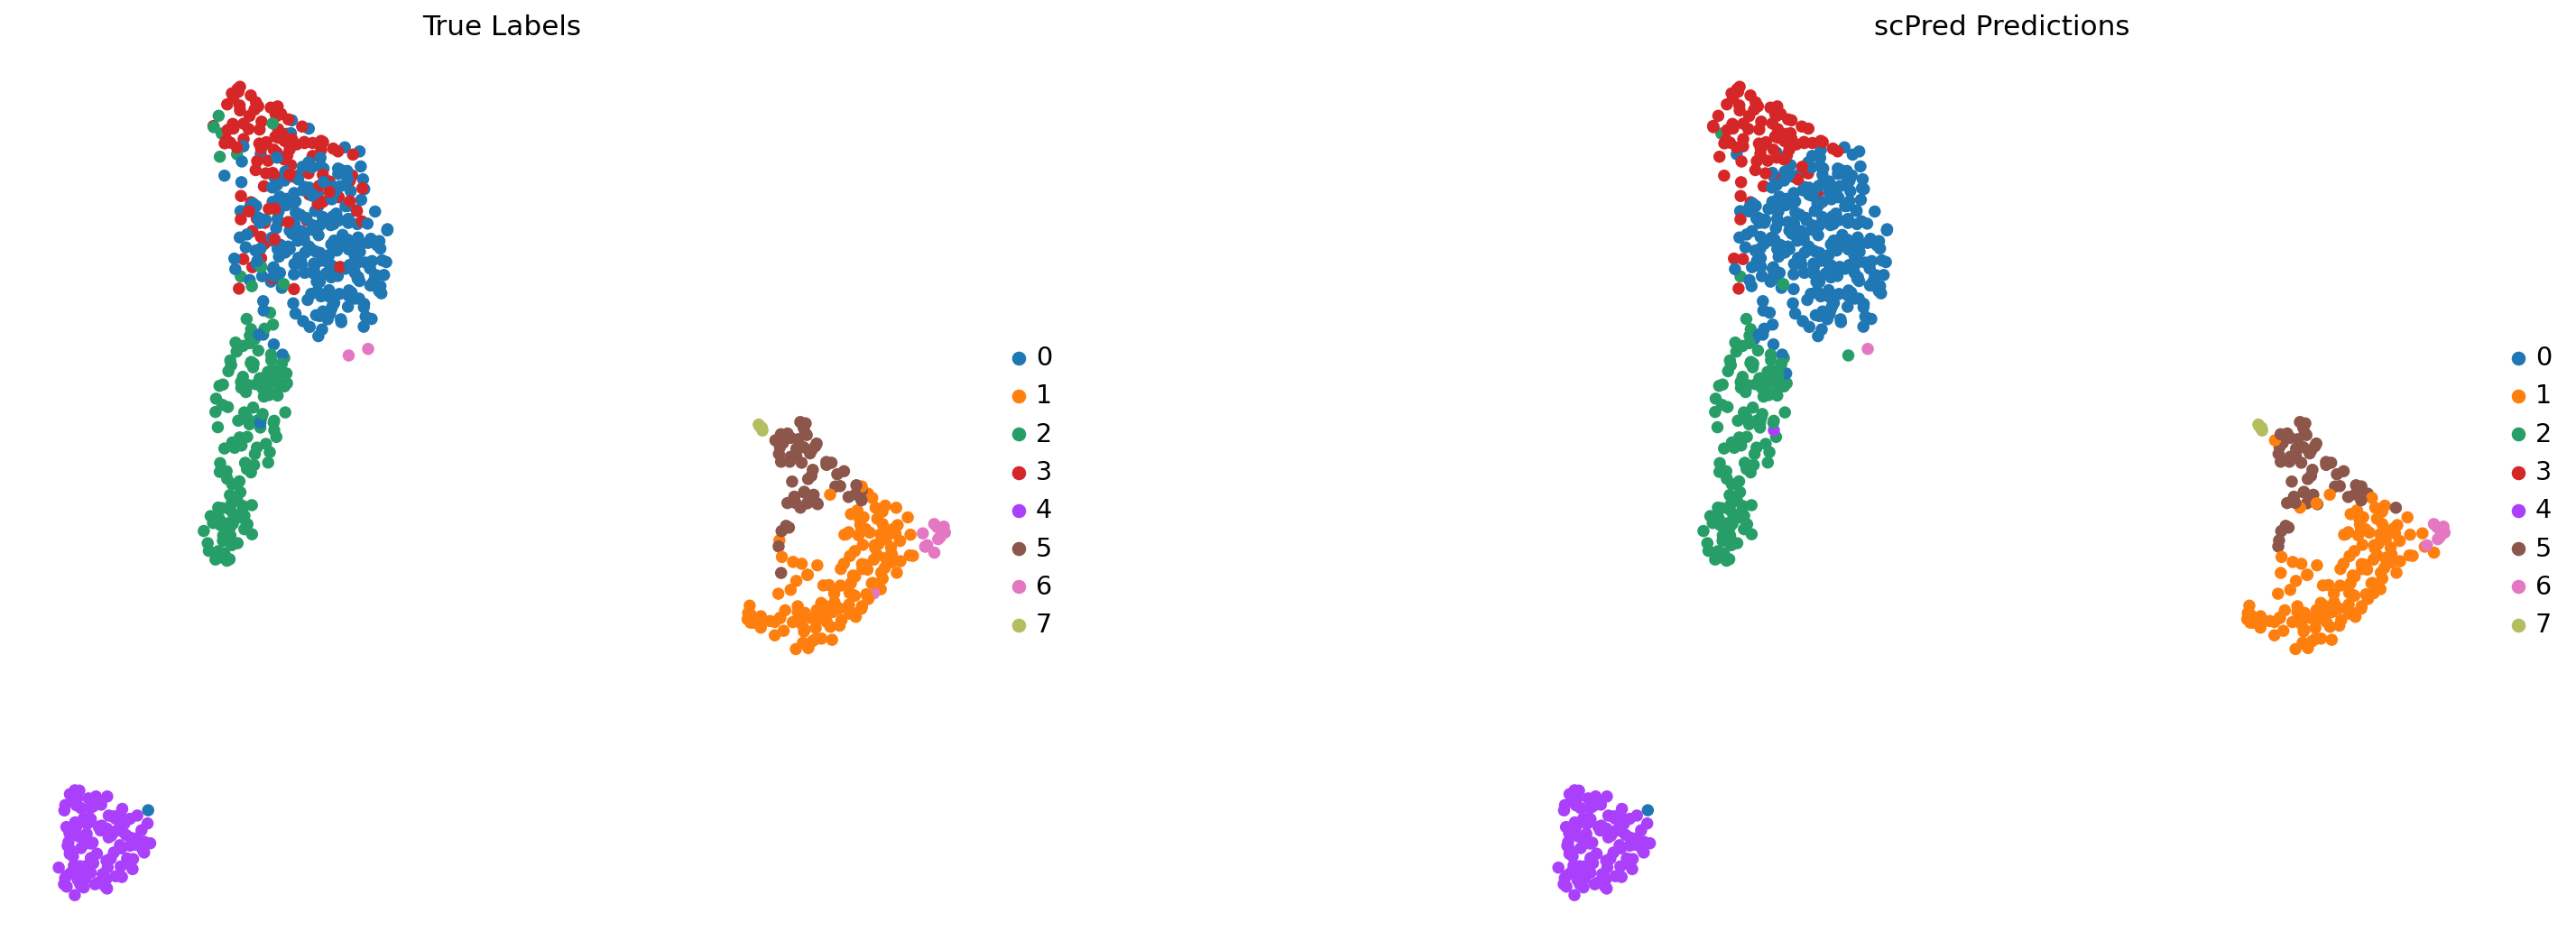

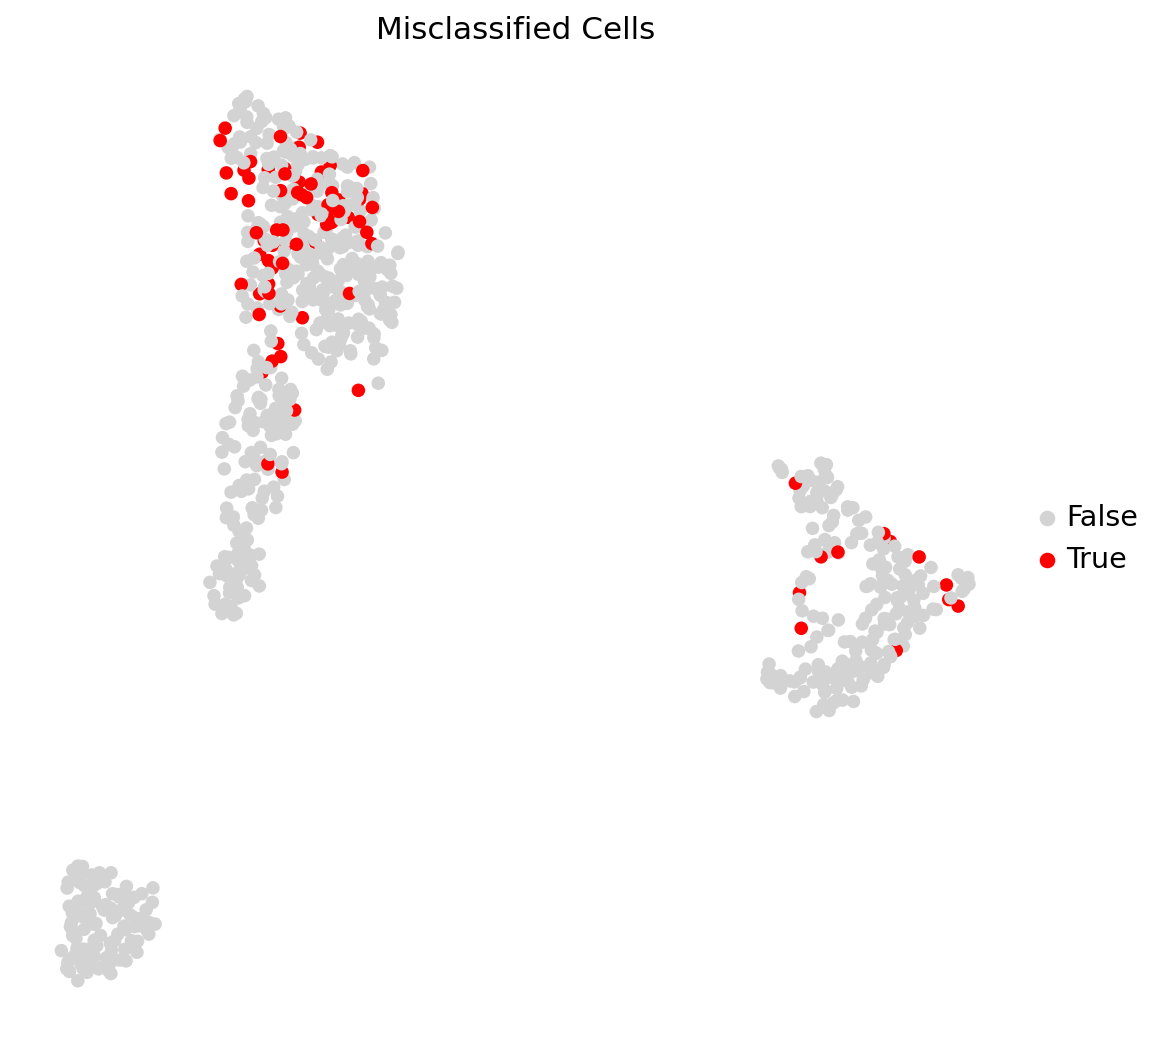

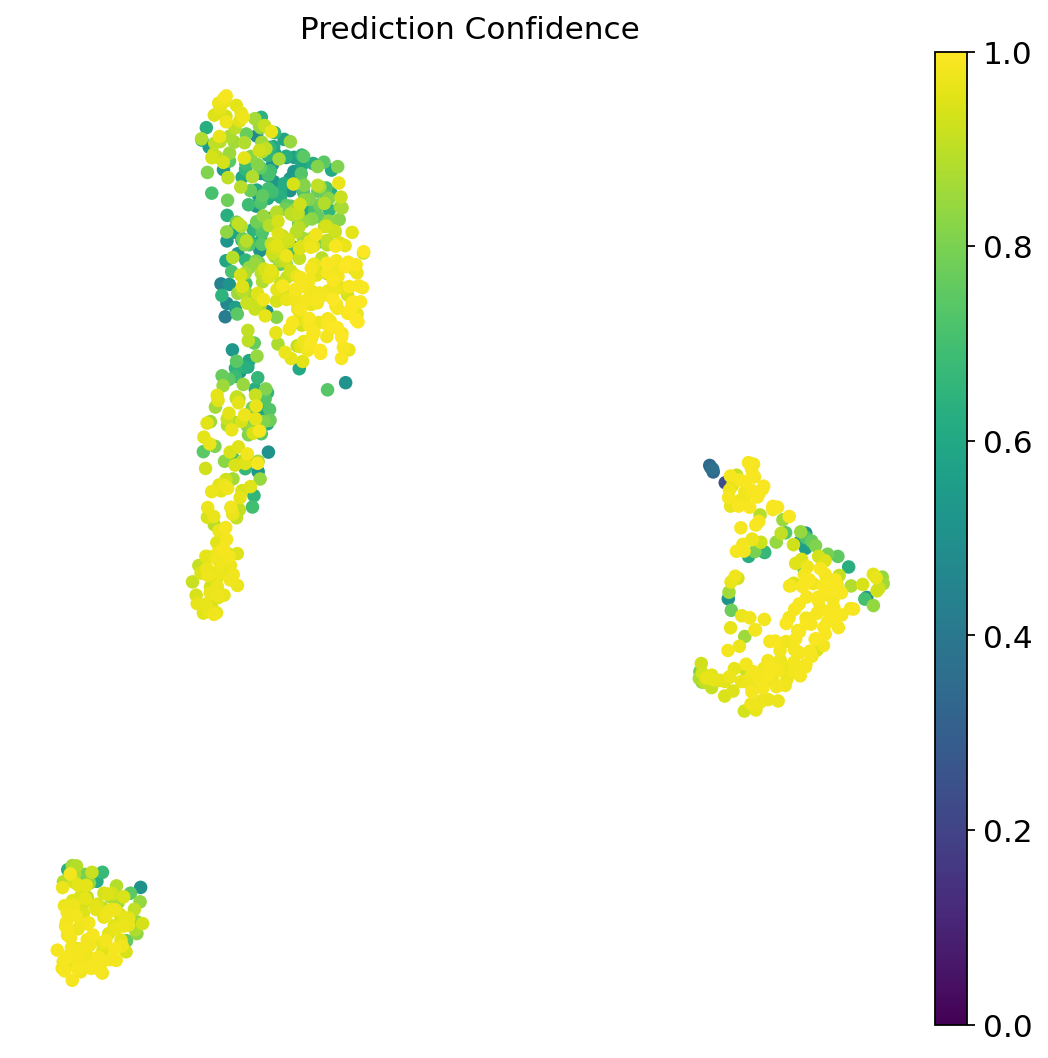

In [6]:
# --- Run Scenario 1 ---
run_scenario(scpred_model, query_adata_raw, threshold=0.0, scenario_name="ANALYSIS SCENARIO 1 (pbmc3k): NO THRESHOLD (0.0)", random_state=RANDOM_STATE)




======== ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8) ========
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 11316 genes to 2000 reference genes...
  Note: 237 reference genes were missing in the query data and filled with zeros.
  Note: 9553 query genes were not in the reference and were dropped.
Genes aligned. New shape: (810, 2000)
Transforming data with fitted StandardScaler...
Data scaled.
Projecting data onto existing PCA space...
Projection finished.
Predicting cell types...
Applied probability thresholding: 173 cells set to 'unassigned' (threshold=0.8).
Prediction finished.
Projected PCs stored in query_adata.obsm['X_scpred_pca']. Cells filtered during preprocessing will have NaN values.
--- ScPred Prediction Complete ---

Query Data with Predictions (first 5 row

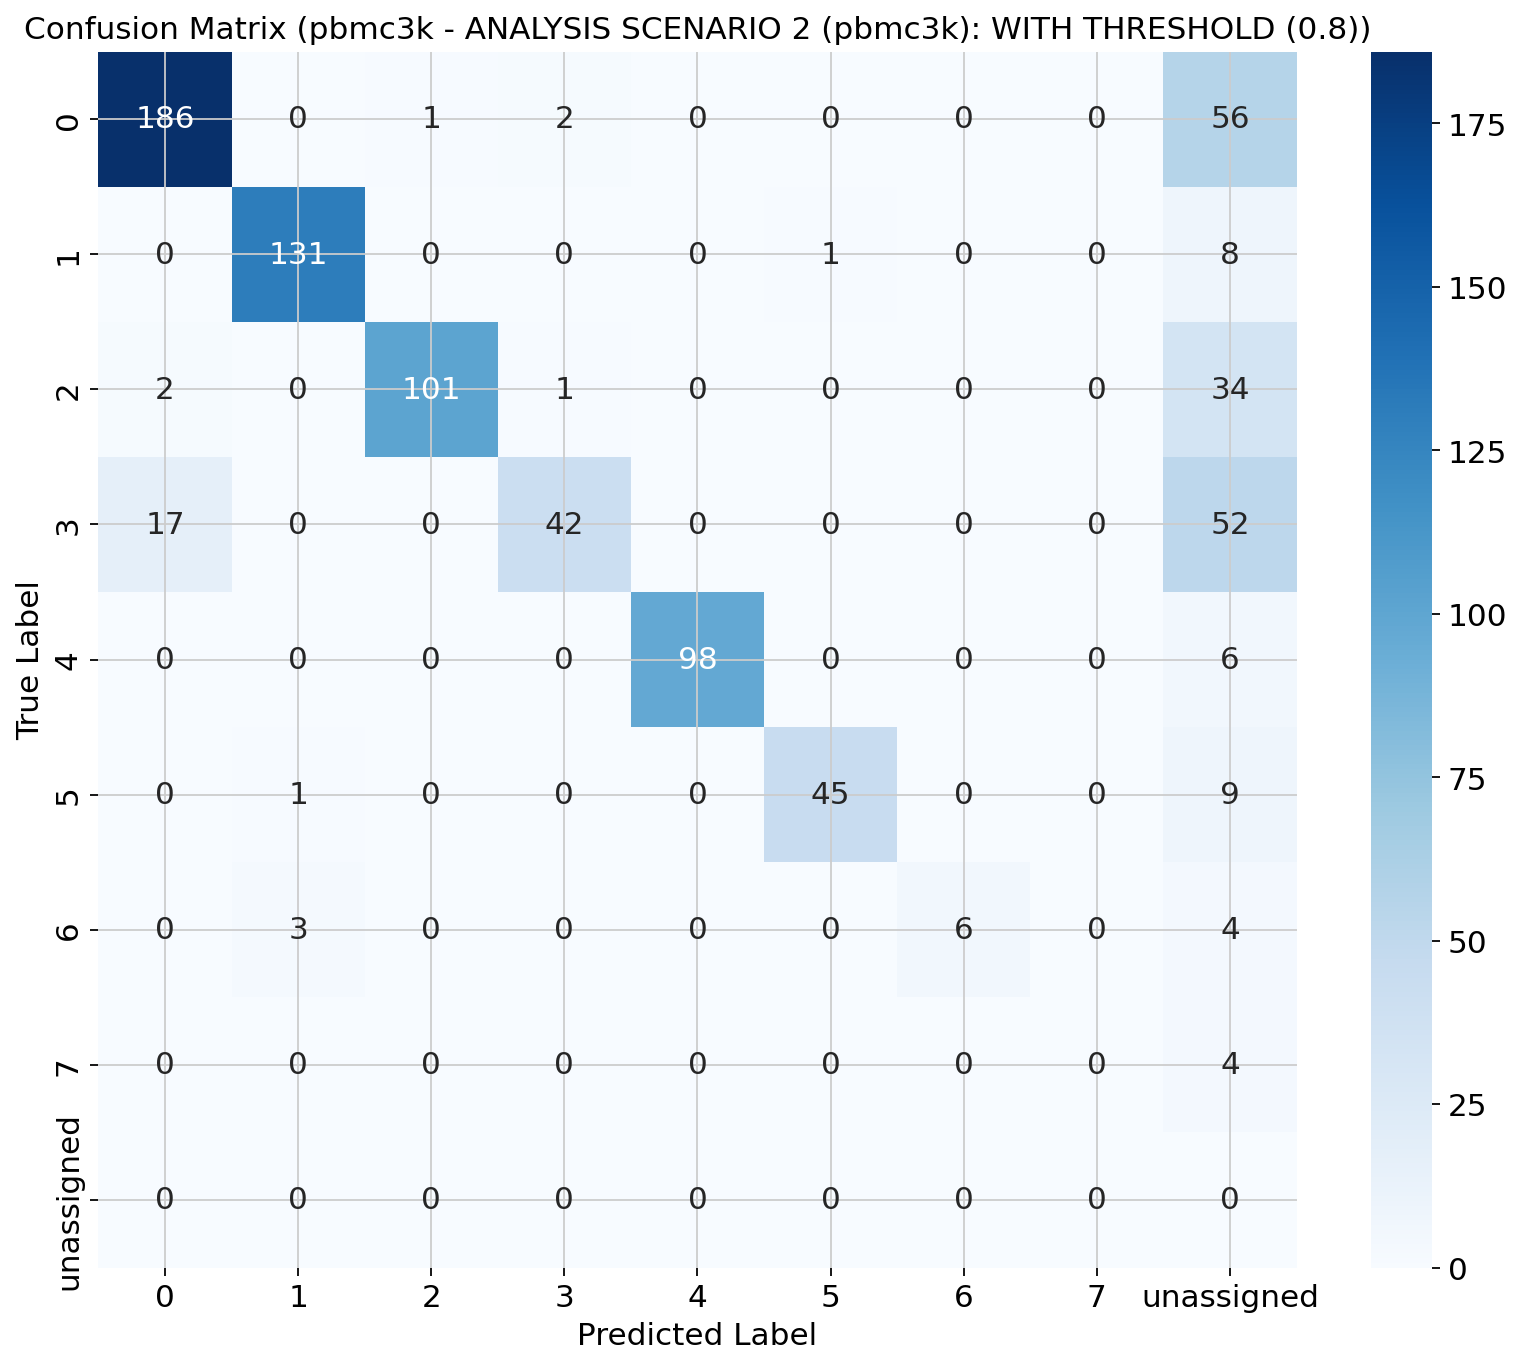


--- Per-Class ROC AUC (ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)) ---


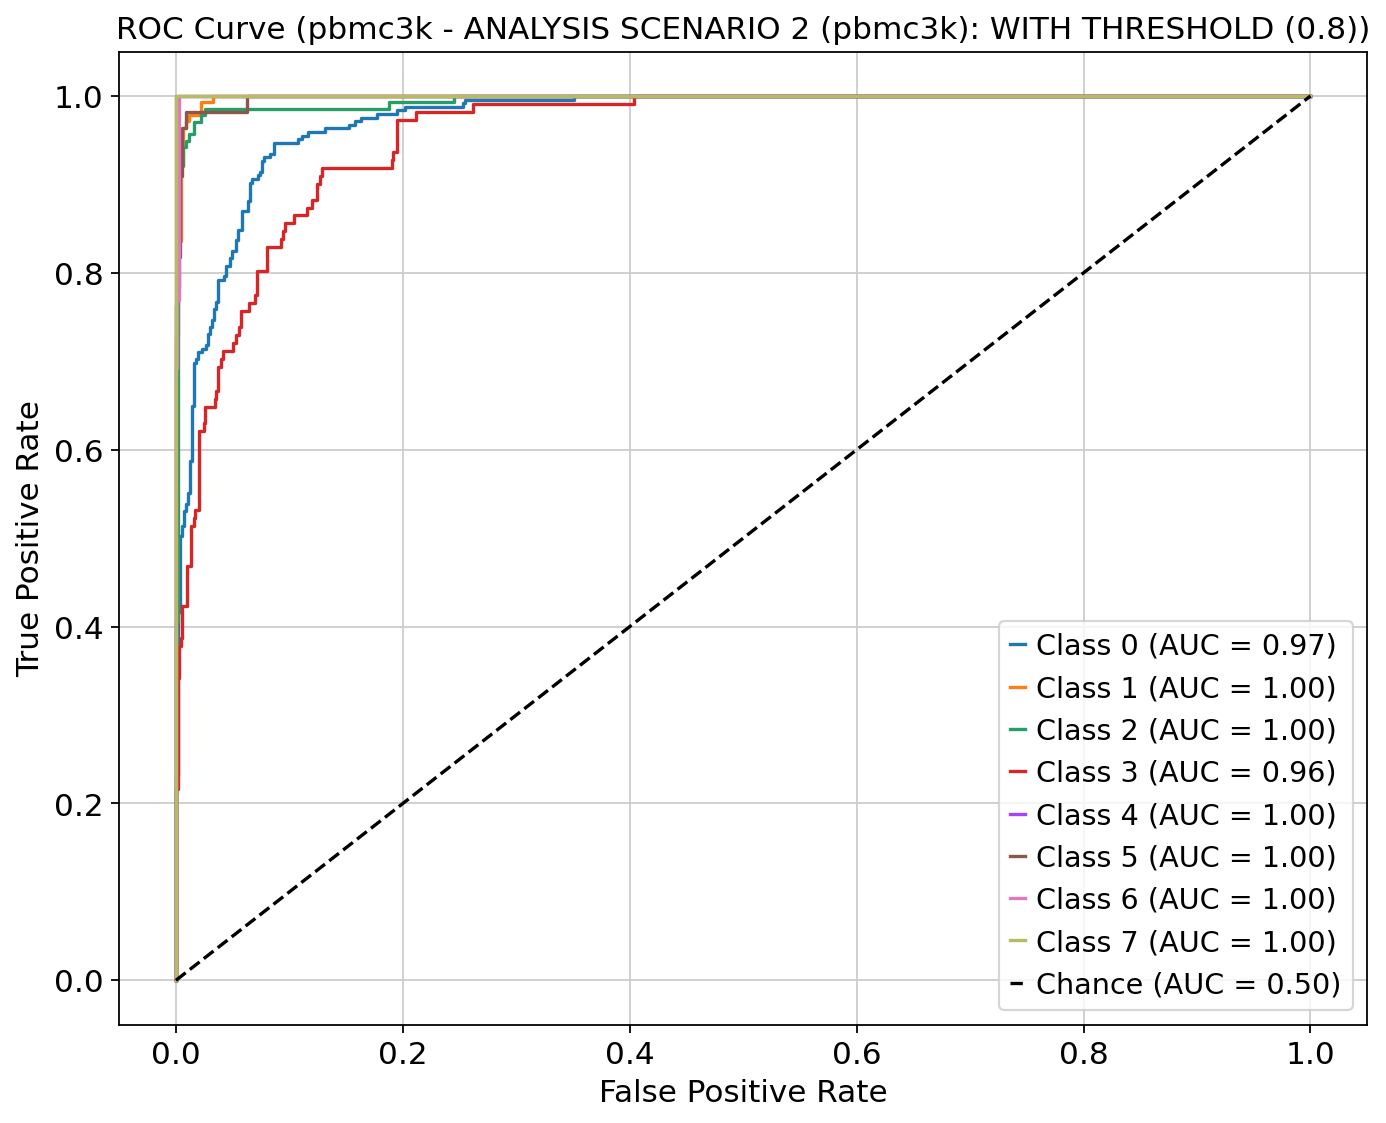


--- Distribution of Prediction Probabilities (Per True Cell Type, ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)) ---


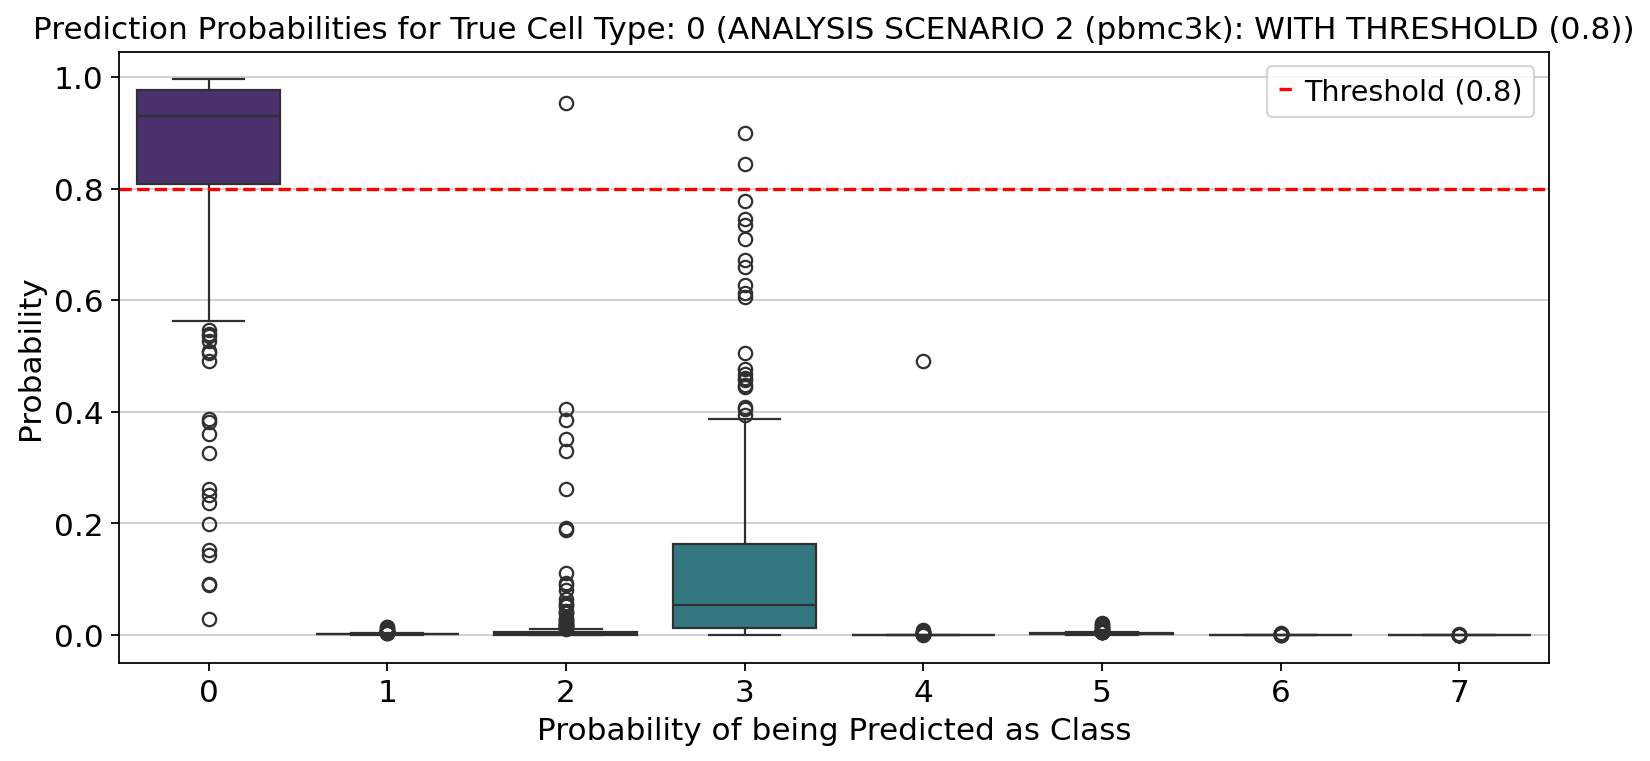

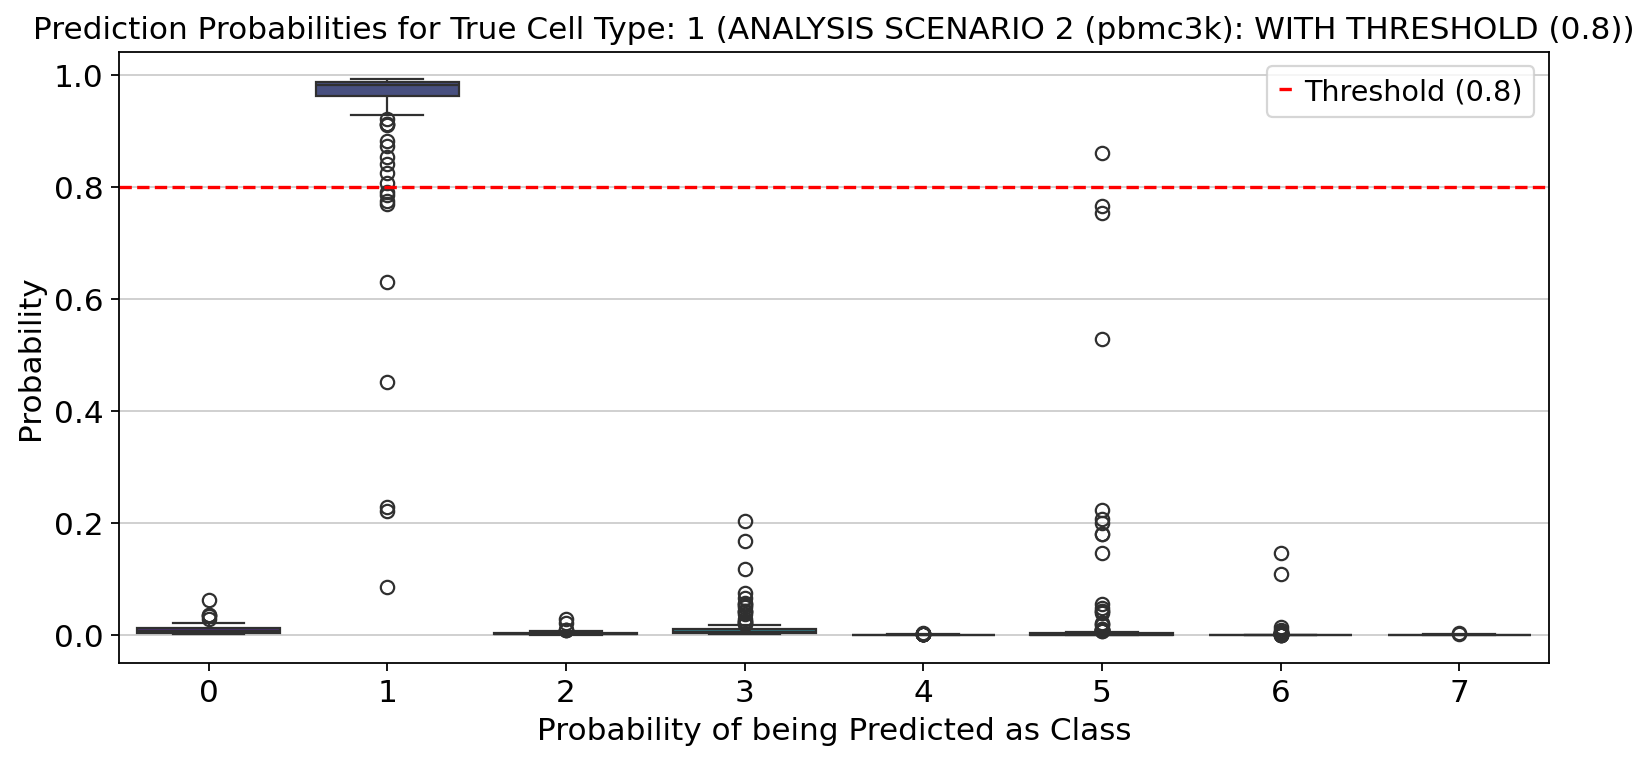

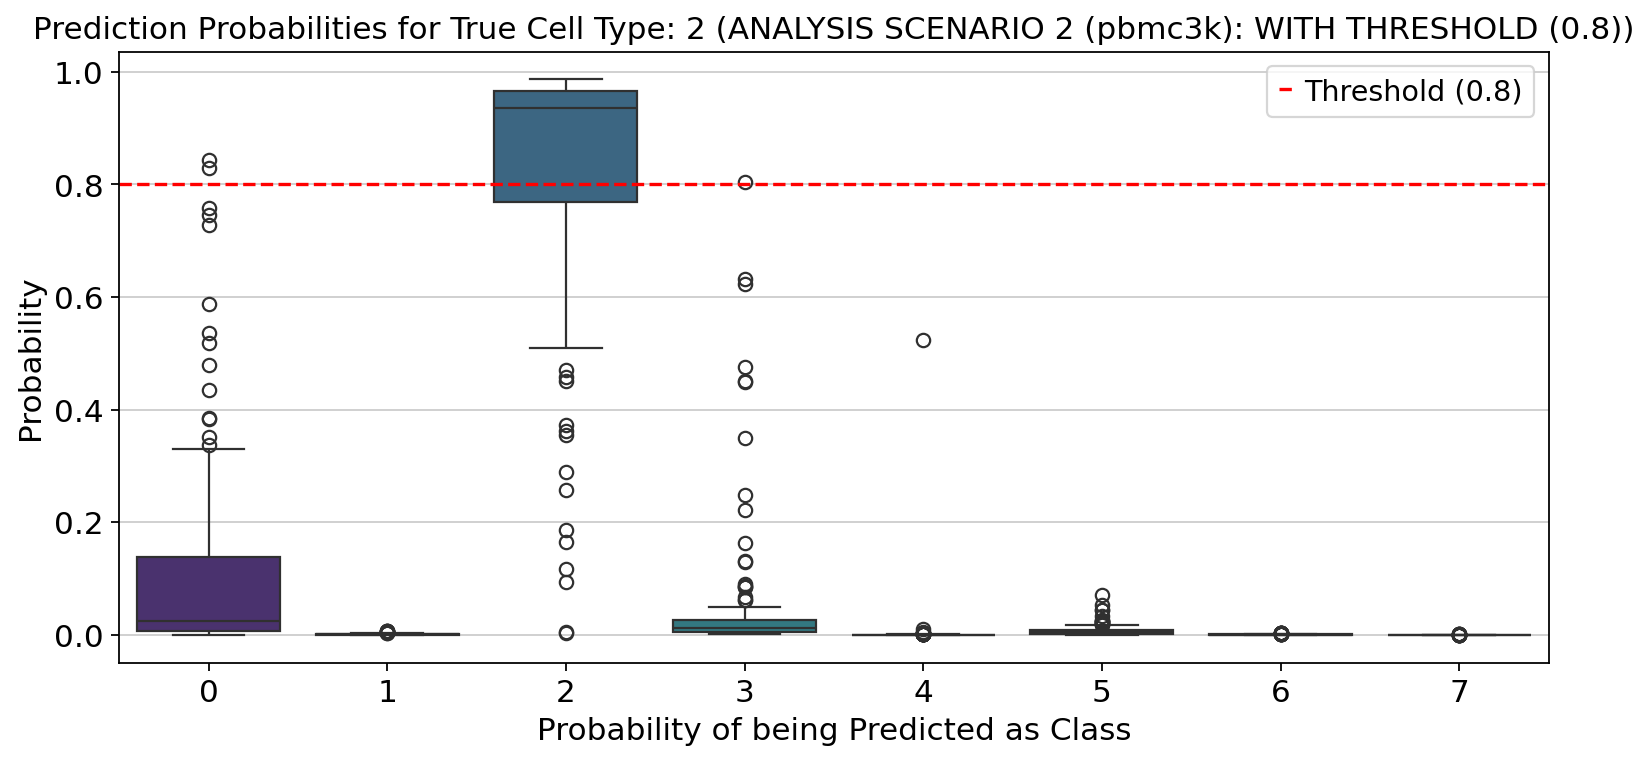

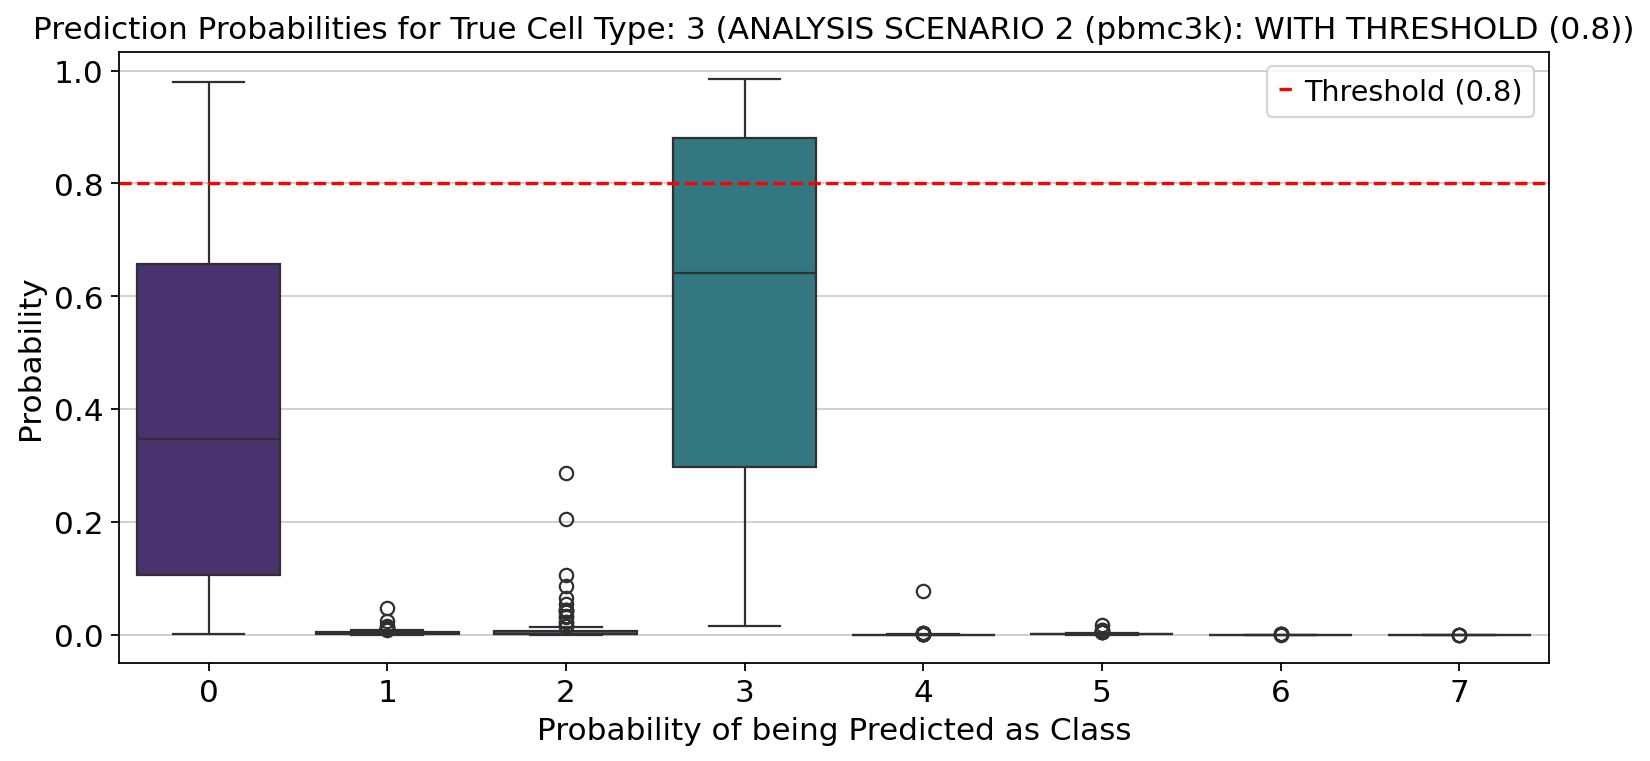

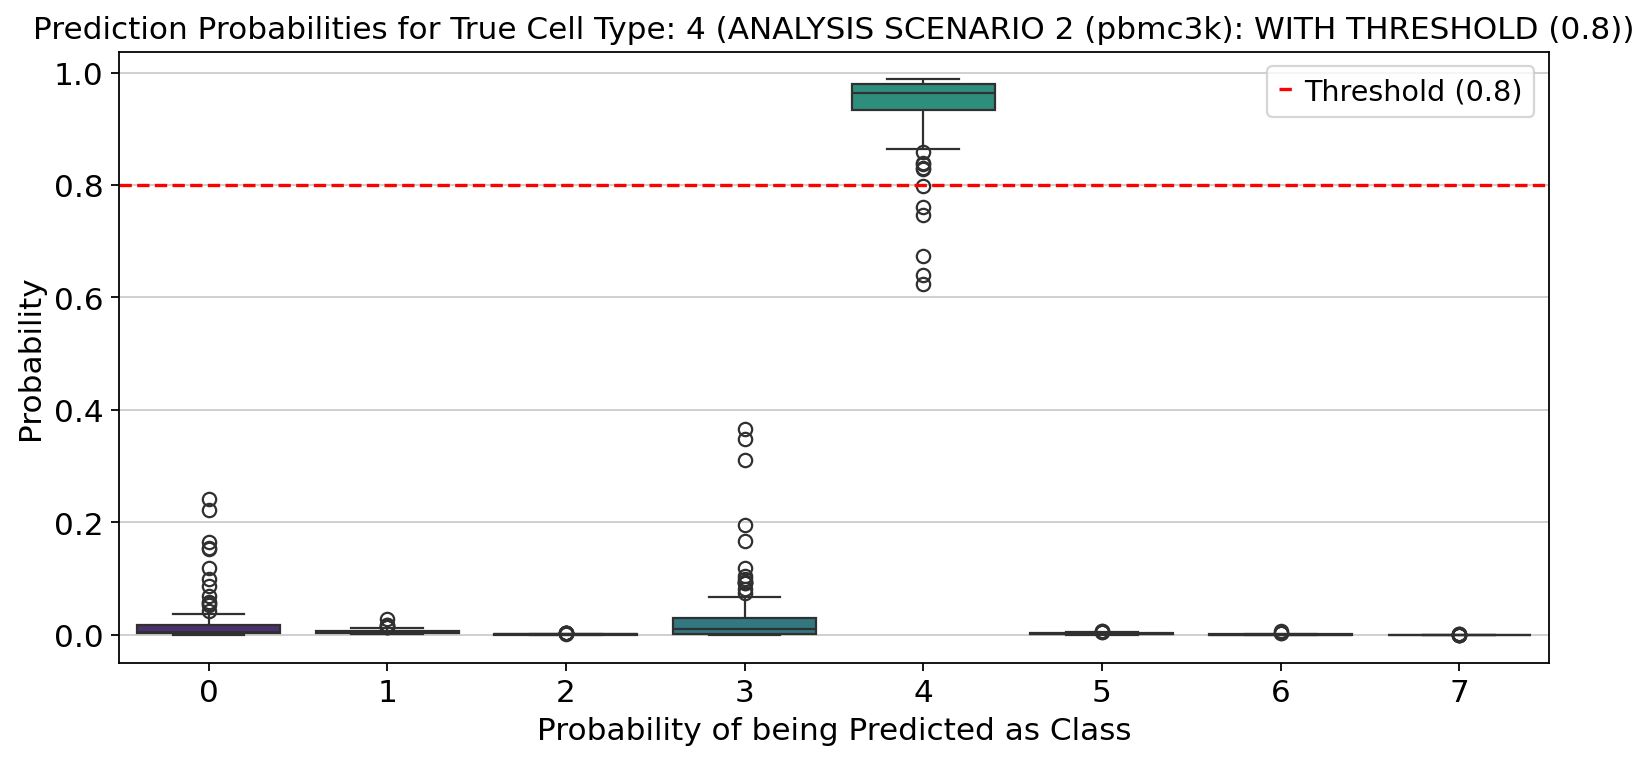

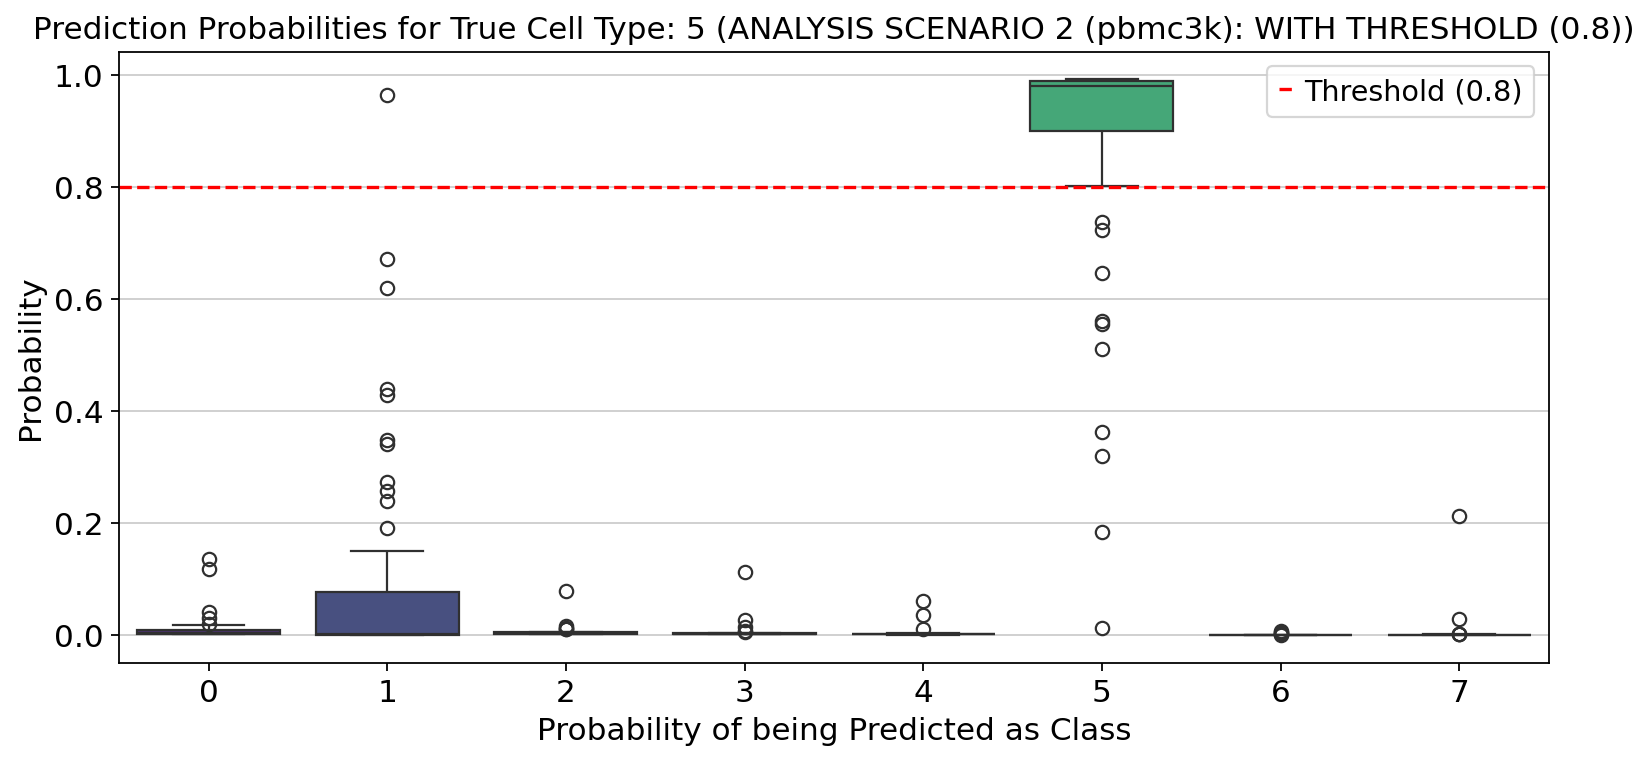

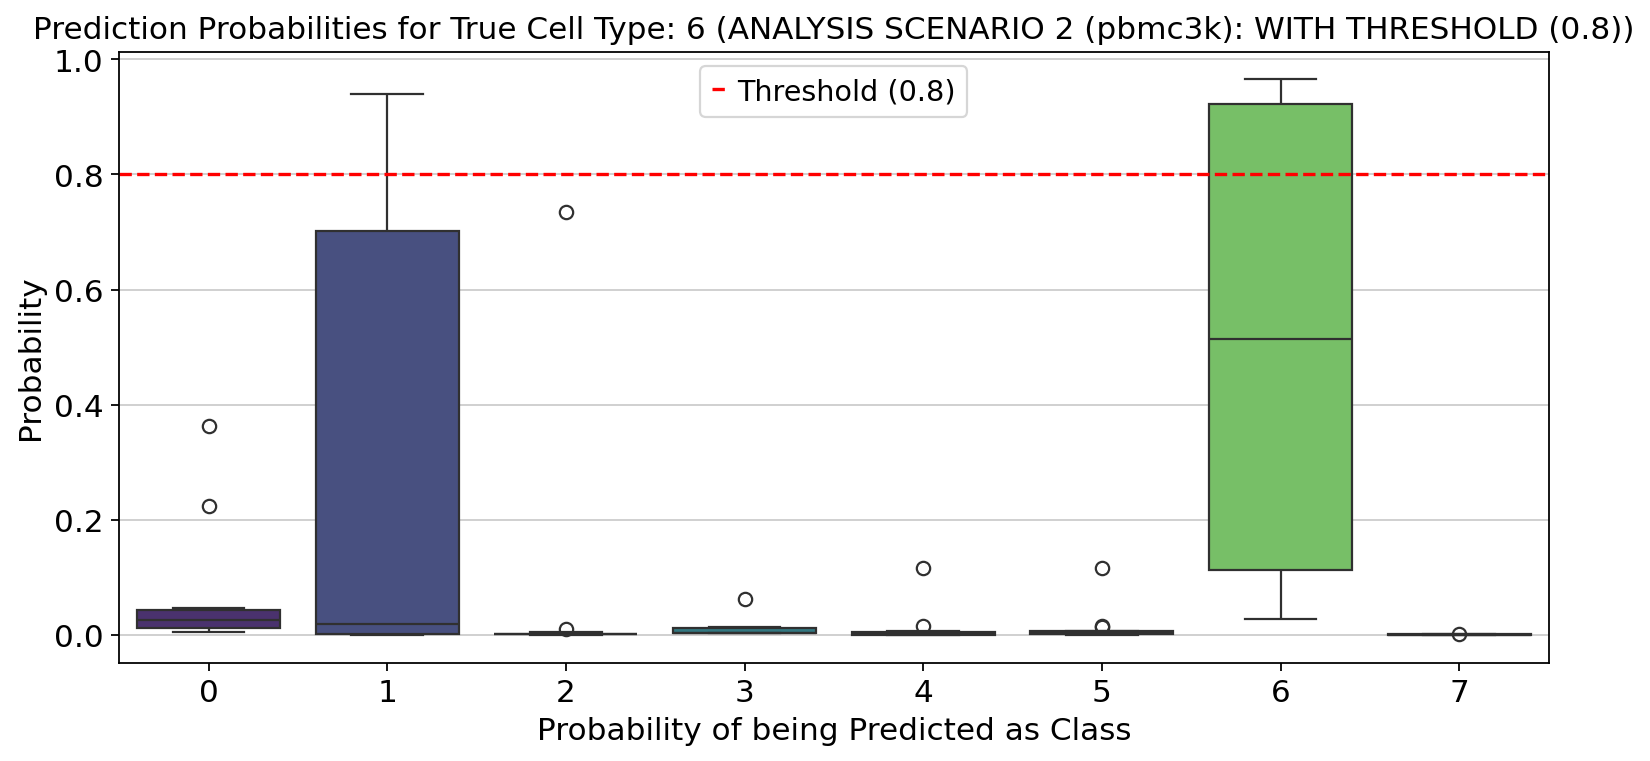

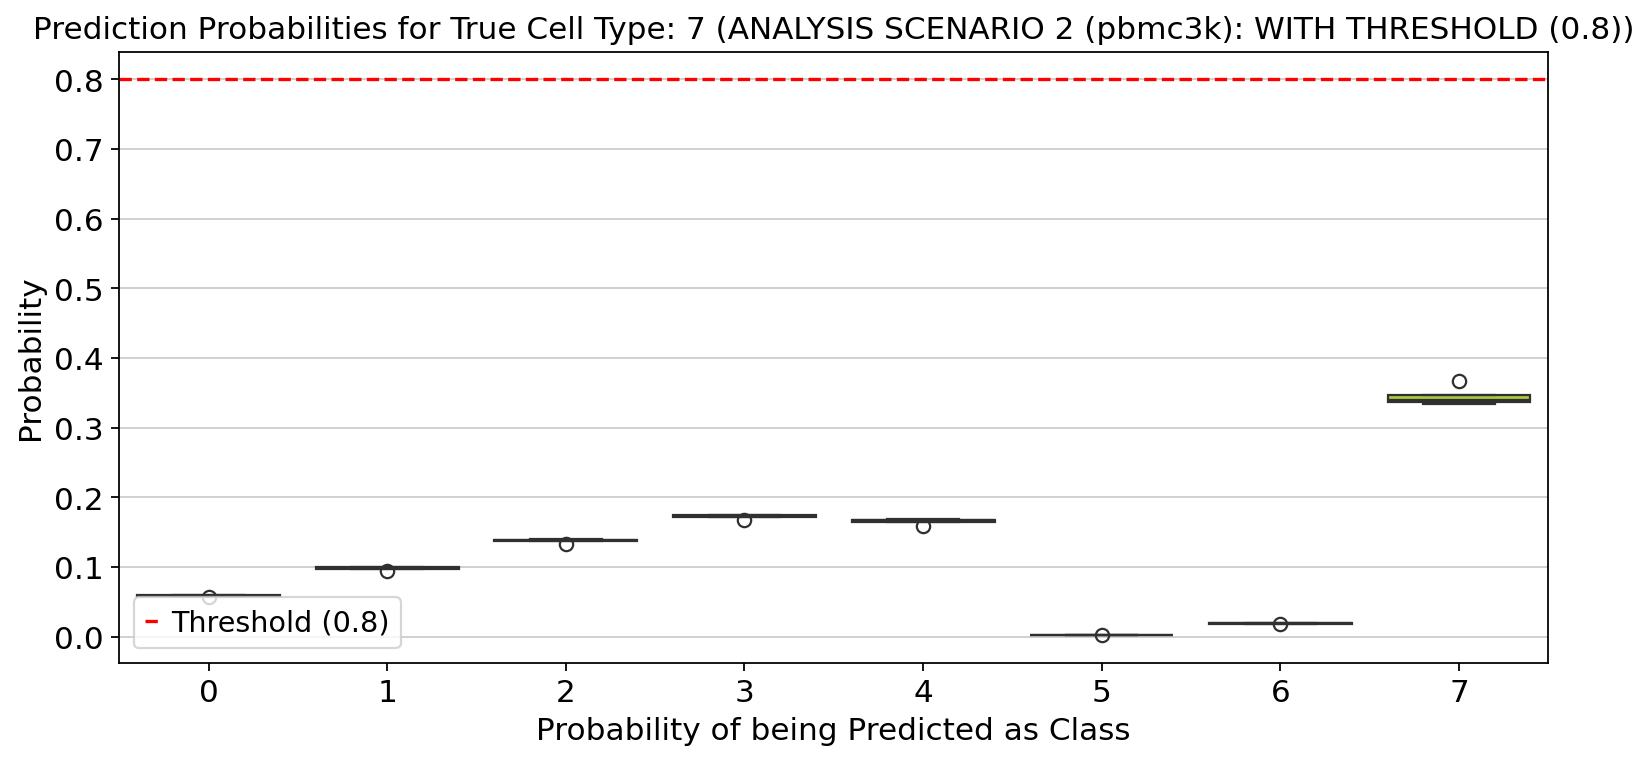


--- Max Prediction Probability per True Cell Type (ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)) ---


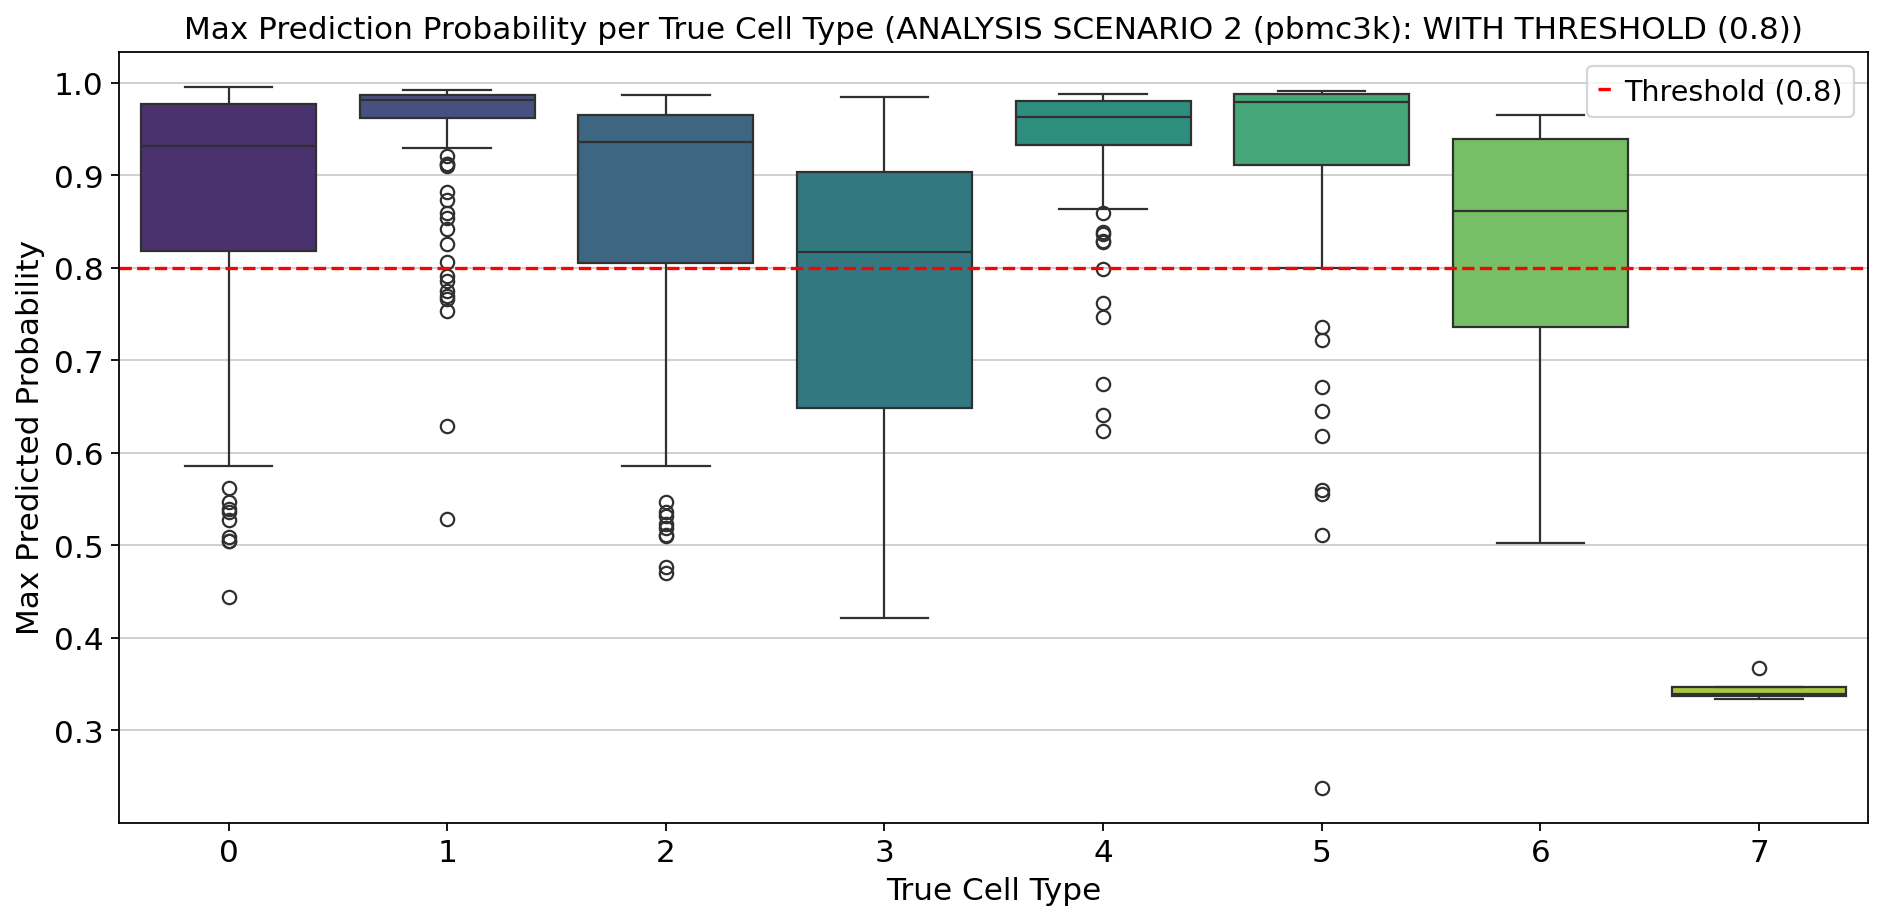


--- Max Prediction Probability per Predicted Label (ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)) ---


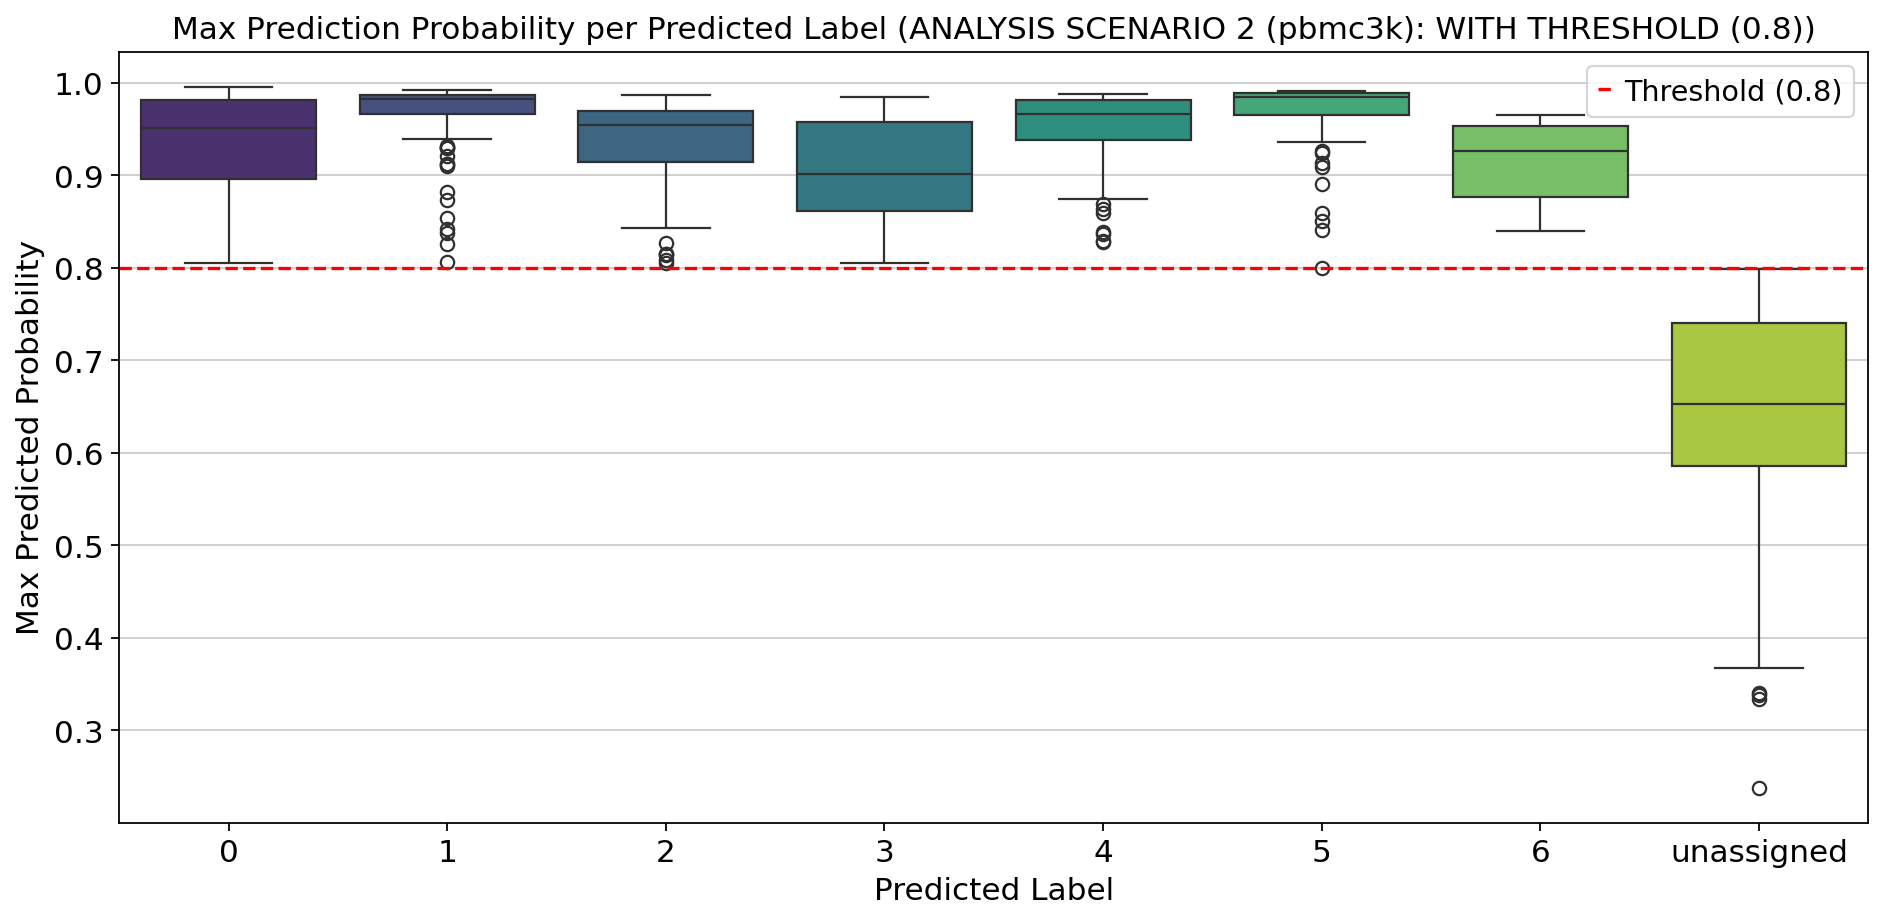


--- UMAP Visualizations (ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)) ---


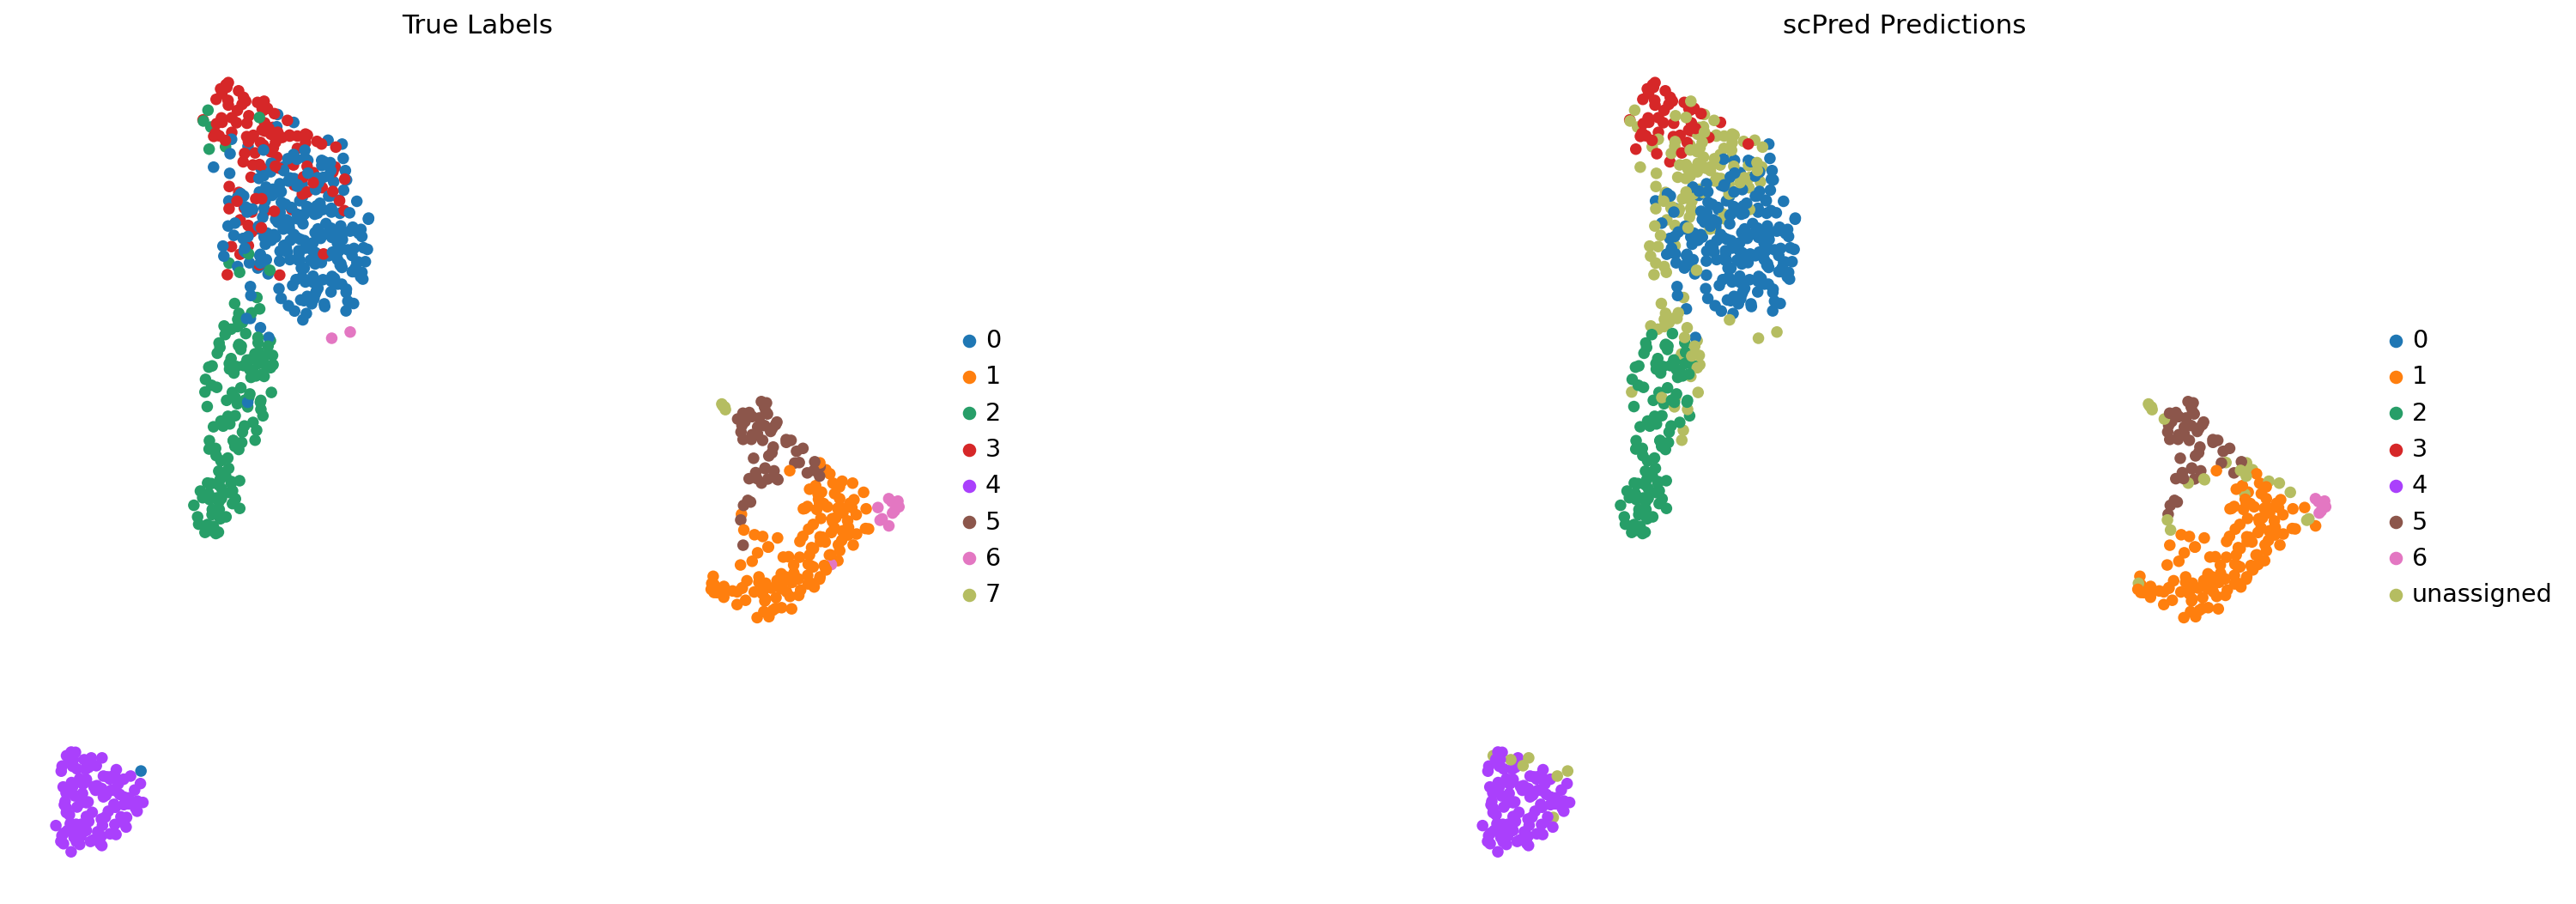

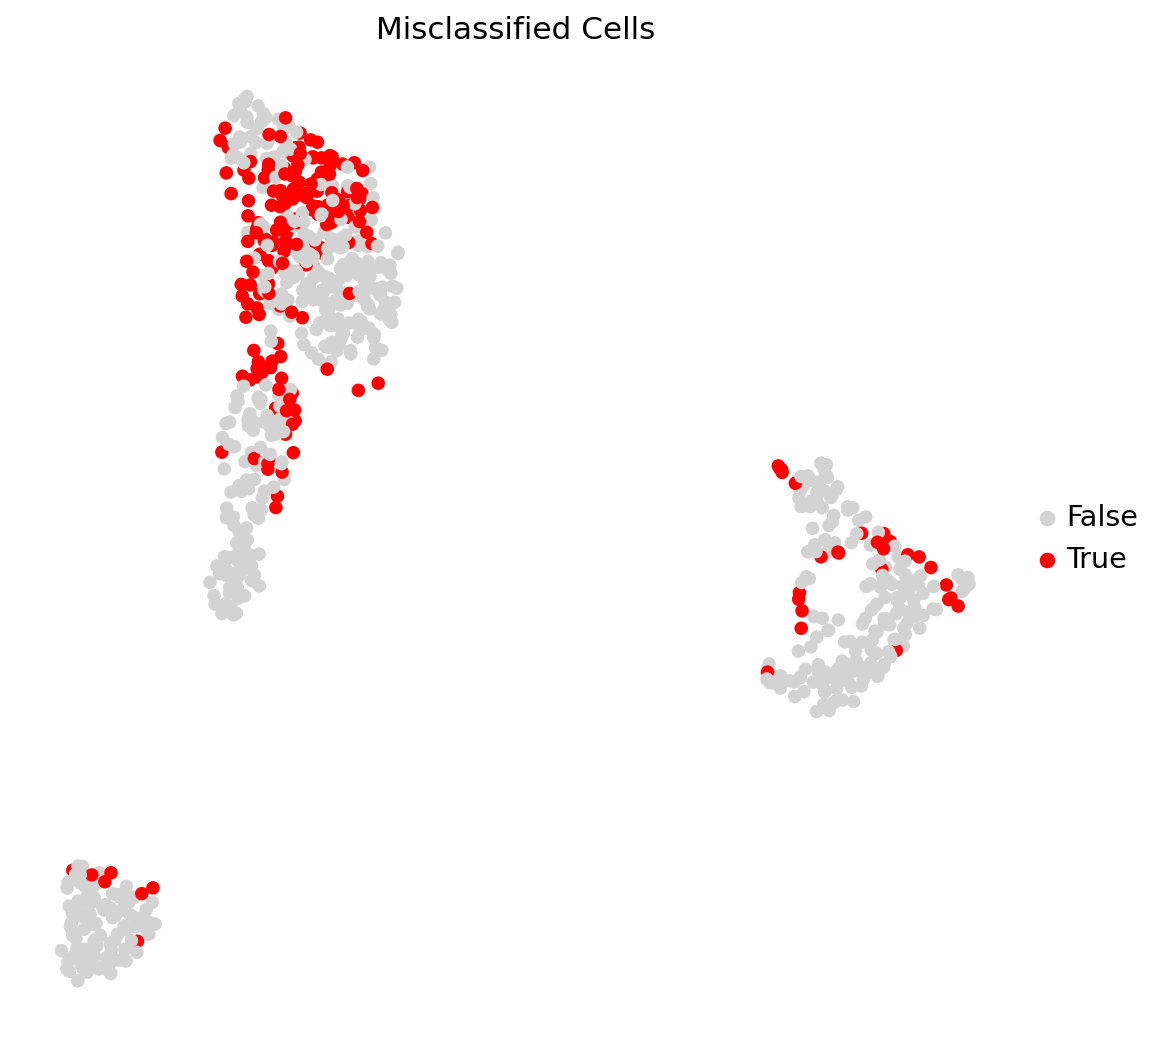

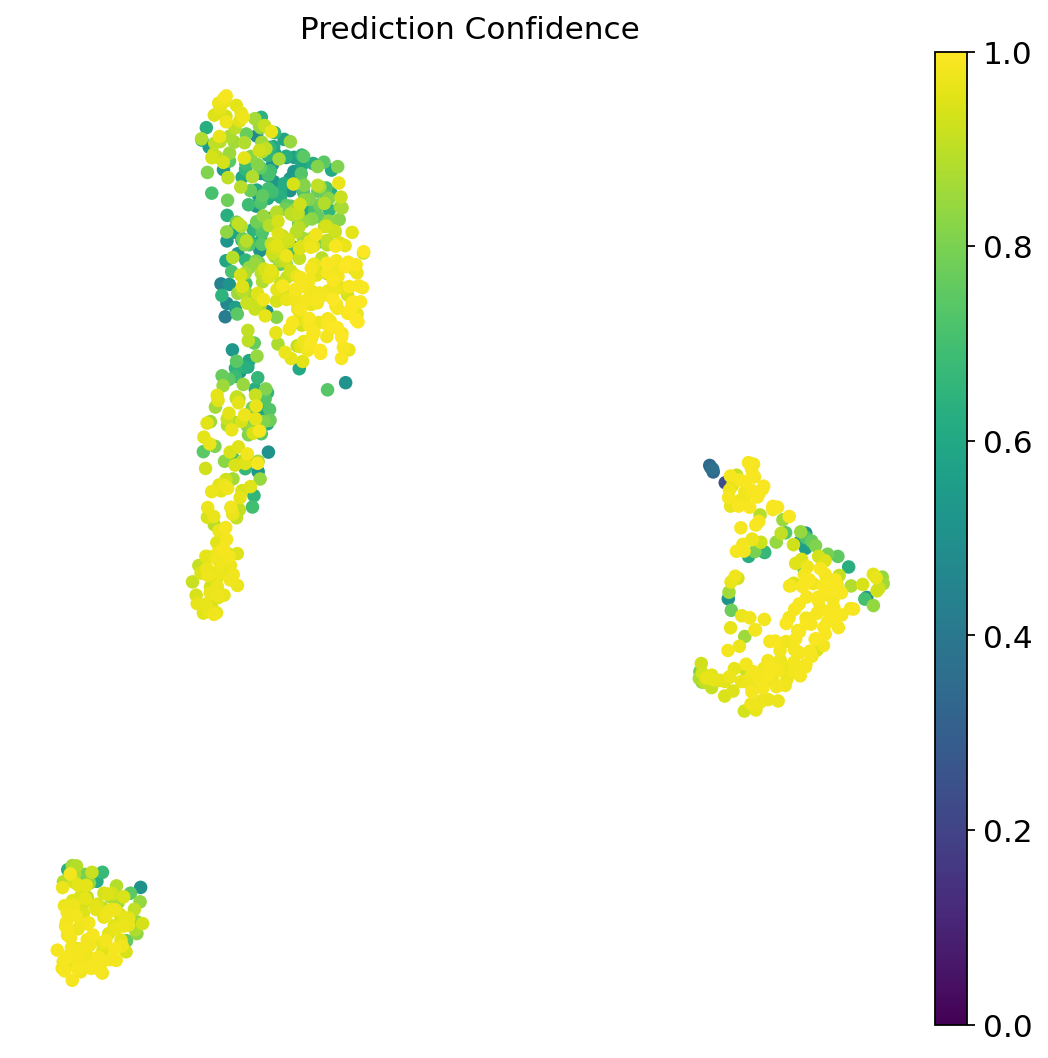


--- pbmc3k Analysis Complete ---


In [7]:
# --- Run Scenario 2 ---
run_scenario(scpred_model, query_adata_raw, threshold=0.8, scenario_name="ANALYSIS SCENARIO 2 (pbmc3k): WITH THRESHOLD (0.8)", random_state=RANDOM_STATE)

print("\n--- pbmc3k Analysis Complete ---")